# Reliability of AMR Phenotype Prediction Under Increasingly Strict Generalization Settings

## 1. Research Question

**How reliable is antimicrobial resistance (AMR) phenotype prediction performance under
increasingly strict generalization settings that prevent different forms of overlap
between related observations?**

Observations in this dataset are not independent: the same species, antibiotic,
species-antibiotic combination, genome/isolate, and genome-antibiotic relationship can all
recur across multiple rows. A test row can therefore be *technically* unseen (a new row
index) while representing a relationship the model has already encountered during training
(e.g. the same species tested against the same antibiotic, just on a different isolate).

This notebook's central contribution is **not** a search for the best classifier. It is a
systematic evaluation framework that measures how estimated performance changes as we
progressively remove different kinds of overlap between training and test data.

## 2. Why Conventional Random Splitting Can Be Optimistic

A conventional random row-level train/test split only guarantees that the exact *rows* differ
between train and test. It does **not** guarantee that the underlying species, antibiotic,
species-antibiotic relationship, or genome differs. If those relationships repeat, a model can
score well by recognizing a previously-seen relationship rather than by learning anything that
transfers to genuinely new biological entities. This notebook quantifies exactly how much
overlap survives under each splitting strategy, rather than assuming it away.

## 3. Four Evaluation Regimes

| # | Regime | What is guaranteed novel in the test set | Mental shorthand |
|---|--------|--------------------------------------------|-------------------|
| 1 | Random row-level split | Nothing beyond the row itself | "New rows" |
| 2 | Unseen Species-Antibiotic | The Species+Antibiotic combination | "New relationship" |
| 3 | Unseen Genome | The genome/isolate | "New isolate" |
| 4 | Leave-One-Species-Out (LOSO) | The species itself | "New species" |

Each regime is strictly harder than the last **along its own axis**, but the axes are
different. A new genome can still belong to a familiar species and a familiar
species-antibiotic relationship. A new species-antibiotic combination can still involve a
genome the model saw under a different antibiotic. Because of this, later sections do **not**
assume that performance must decrease monotonically across regimes 1-4; the split-integrity
audit (Section 10) verifies exactly which overlaps survive in each regime and results are
interpreted accordingly.

## 4. What Each Regime Tests

- **Random split**: conventional ML evaluation, reported mainly as a baseline for comparison,
  not as evidence of strong generalization.
- **Unseen Species-Antibiotic (GroupKFold on Species+Antibiotic)**: can the model generalize to
  a species-antibiotic relationship it has never seen, even though it may have seen the same
  genome or species elsewhere?
- **Unseen Genome (GroupKFold on Genome ID)**: can the model generalize to a new bacterial
  isolate, even though the species-antibiotic relationship itself may be familiar?
- **Leave-One-Species-Out**: can the model generalize to an entirely new species? This is the
  strongest cross-generalization test available in this dataset (only 5 species, so it is
  treated as a small-sample exploratory analysis, not a definitive claim).

## 5. Main Hypotheses

**H1**: Performance estimated from conventional random row-level splitting will be more
optimistic (higher) than performance estimated once species-antibiotic, genome, or species
overlap is controlled.

**H2**: A substantial share of "predictive" performance under weak evaluation regimes is
attributable to simple structural memorization (majority-label lookup by
Species+Antibiotic or Genome+Antibiotic) rather than to information that would let a
classifier generalize to new biological entities.

**H3**: Label conflicts (the same Species+Antibiotic or Genome+Antibiotic combination
receiving both Resistant and Susceptible labels in the data) are associated with lower,
harder-to-improve prediction accuracy for the affected observations.

These hypotheses are tested empirically below and the conclusions in Section 24 are drawn
from the actual computed results, not assumed in advance.

## 6. Important Scientific Qualification (read before interpreting any result)

The `Resistant Phenotype` labels in this dataset are recorded values associated with
upstream computational and laboratory methods documented in BV-BRC (see Section 2:
Dataset Provenance). They are **not** independently re-verified laboratory ground truth
collected by this project. Everywhere in this notebook, "AMR prediction" means
**prediction of the recorded Resistant Phenotype label in this BV-BRC-derived dataset**,
not a claim about true clinical resistance.


In [ ]:
import json
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost as xgb
import shap

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import (
    StratifiedKFold, GroupKFold, LeaveOneGroupOut, learning_curve
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, recall_score, confusion_matrix,
    ConfusionMatrixDisplay, brier_score_loss
)
from sklearn.calibration import calibration_curve

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s",
                     datefmt="%H:%M:%S")
logger = logging.getLogger("amr_pipeline")
# Only the specific noisy/uninformative warning categories below are silenced; all other
# warnings remain visible, per the instruction to avoid blanket warning suppression.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*use_label_encoder.*")

# --- Reproducibility configuration -----------------------------------------------------
SEED = 42                              # Master seed: data ordering, default model init, main splits
ROBUSTNESS_SEEDS = list(range(10))     # 10 seeds used ONLY for model-seed robustness (Section 14)
N_PERMUTATIONS = 200                   # Label permutations for the permutation test (Section 15)
N_BOOTSTRAP = 1000                     # Resamples for group-aware / row bootstrap confidence intervals
N_SPLITS_GROUPED = 5                   # Folds for GroupKFold-based regimes
DATA_PATH = Path("BVBRC_genome_amr.csv")   # If running elsewhere, update this path
if not DATA_PATH.exists():
    # Fall back to common alternate filenames (e.g. the original upload name) so the notebook
    # still runs without manual editing if the CSV wasn't renamed.
    _candidates = list(Path(".").glob("*BVBRC_genome_amr.csv")) + list(Path(".").glob("*BVBRC*.csv"))
    if _candidates:
        DATA_PATH = _candidates[0]
        logger.info("DATA_PATH not found at default name; using detected file instead: %s", DATA_PATH)
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

np.random.seed(SEED)

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300, "font.family": "sans-serif",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#333333",
})
PALETTE = {"primary": "#2E5C8A", "secondary": "#C0392B", "tertiary": "#27AE60",
           "neutral": "#7F8C8D", "highlight": "#E67E22", "purple": "#8E44AD"}
REGIME_COLORS = {"Random row-level": "#7F8C8D", "Unseen Species-Antibiotic": "#2E5C8A",
                  "Unseen Genome": "#27AE60", "Leave-One-Species-Out": "#C0392B"}

logger.info("Package versions: pandas=%s numpy=%s scikit-learn=%s xgboost=%s shap=%s",
            pd.__version__, np.__version__, sklearn.__version__, xgb.__version__, shap.__version__)
logger.info("SEED=%d | ROBUSTNESS_SEEDS=%s | N_PERMUTATIONS=%d | N_BOOTSTRAP=%d",
            SEED, ROBUSTNESS_SEEDS, N_PERMUTATIONS, N_BOOTSTRAP)
logger.info("Sources of randomness in this notebook: (1) train/test SPLITTING within a fixed "
            "regime -> controlled by SEED for the main run, varied only where split-uncertainty "
            "is explicitly being studied; (2) MODEL initialization/bootstrapping inside an "
            "algorithm -> varied across ROBUSTNESS_SEEDS in Section 14, holding the split fixed; "
            "(3) BOOTSTRAP resampling for confidence intervals (Section 15); "
            "(4) LABEL PERMUTATION for the null distribution (Section 16). "
            "These four sources are kept conceptually and computationally separate throughout.")


**Note on scope (Section 48 compliance):** this notebook deliberately uses only
Logistic Regression, Random Forest, Gradient Boosting, and XGBoost, with default/lightly
controlled hyperparameters (documented in Section 8). No neural networks, transformer
models, or large hyperparameter searches are used. The empirical contribution of this
project is the evaluation framework (Sections 9-11) and what it reveals about the models
above, not a search for a better model.

---
# 1. Research Question & Experimental Design

Recap of the experimental design as a data structure, so downstream code and text stay in
sync with the plan described above.

In [ ]:
EXPERIMENTAL_DESIGN = pd.DataFrame([
    dict(regime="Random row-level", guarantees_novel="row only",
         grouping_key="none (stratified by label)", n_folds=N_SPLITS_GROUPED),
    dict(regime="Unseen Species-Antibiotic", guarantees_novel="Species+Antibiotic combination",
         grouping_key="Species | Antibiotic", n_folds=N_SPLITS_GROUPED),
    dict(regime="Unseen Genome", guarantees_novel="Genome ID",
         grouping_key="Genome ID", n_folds=N_SPLITS_GROUPED),
    dict(regime="Leave-One-Species-Out", guarantees_novel="Species",
         grouping_key="Species", n_folds="= number of species (5)"),
])
EXPERIMENTAL_DESIGN


,regime,guarantees_novel,grouping_key,n_folds
0,Random row-level,row only,none (stratified by label),5
1,Unseen Species-Antibiotic,Species+Antibiotic combination,Species | Antibiotic,5
2,Unseen Genome,Genome ID,Genome ID,5
3,Leave-One-Species-Out,Species,Species,= number of species (5)


---
# 2. Dataset Provenance

**Source**: BV-BRC (Bacterial and Viral Bioinformatics Resource Center) genome-level AMR
records, provided by the user as a CSV export.

**Filename**: `BVBRC_genome_amr.csv`

**What this file is**: one row per (genome, antibiotic) AMR test/prediction record, combining
laboratory-derived and computationally-derived resistance calls, as exported from BV-BRC's
genome AMR data.

The `Resistant Phenotype` field is the recorded outcome; the `Computational Method`,
`Computational Method Performance`, and `Evidence` fields describe *how* many of these calls
were produced (see Section 16 for why this matters). We do not have access to raw laboratory
bench data, only what BV-BRC has recorded.


In [ ]:
df_raw = pd.read_csv("/content/BVBRC_genome_amr.csv")
logger.info("Loaded raw file: %d rows, %d columns", *df_raw.shape)

DATA_DICTIONARY = pd.DataFrame([
    dict(field="Genome ID", meaning="BV-BRC numeric genome identifier (isolate-level)"),
    dict(field="Genome Name", meaning="Free-text organism + strain name, e.g. 'Escherichia coli AMR0264'"),
    dict(field="Taxon ID", meaning="NCBI taxonomy ID; used to cross-check the derived Species field (Section 4)"),
    dict(field="Antibiotic", meaning="Antibiotic tested against the genome"),
    dict(field="Resistant Phenotype", meaning="Target label: 'Resistant' or 'Susceptible' (or missing, see Section 3)"),
    dict(field="Computational Method", meaning="Name of the upstream model/pipeline that produced or supported the call, e.g. 'SIR XGBoost Model'"),
    dict(field="Computational Method Performance", meaning="Free-text upstream self-reported performance (e.g. an F1 score) for that Computational Method"),
    dict(field="Evidence", meaning="BV-BRC evidence-type annotation for the record"),
    dict(field="Measurement / Measurement Value / Measurement Unit", meaning="Lab measurement fields (e.g. MIC value+unit) where available"),
])
print(f"Raw file shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
DATA_DICTIONARY


Raw file shape: 1493 rows x 21 columns


,field,meaning
0,Genome ID,BV-BRC numeric genome identifier (isolate-level)
1,Genome Name,"Free-text organism + strain name, e.g. 'Escher..."
2,Taxon ID,NCBI taxonomy ID; used to cross-check the deri...
3,Antibiotic,Antibiotic tested against the genome
4,Resistant Phenotype,Target label: 'Resistant' or 'Susceptible' (or...
5,Computational Method,Name of the upstream model/pipeline that produ...
6,Computational Method Performance,Free-text upstream self-reported performance (...
7,Evidence,BV-BRC evidence-type annotation for the record
8,Measurement / Measurement Value / Measurement ...,Lab measurement fields (e.g. MIC value+unit) w...


---
# 3. Dataset Loading & Label Handling

Only rows with a recorded `Resistant Phenotype` are usable for supervised learning. Rows
without a label (in this dataset, entirely associated with the `MIC XGBoost Model`
Computational Method — see Section 16) are **excluded from all model training and
evaluation** and are reported separately, never treated as having an implicit target.

In [ ]:
n_total = len(df_raw)
label_counts_raw = df_raw['Resistant Phenotype'].value_counts(dropna=False)
print("Resistant Phenotype value counts (raw, including missing):")
print(label_counts_raw)

unexpected_labels = set(df_raw['Resistant Phenotype'].dropna().unique()) - {'Resistant', 'Susceptible'}
if unexpected_labels:
    logger.warning("Unexpected label values found and NOT silently dropped: %s", unexpected_labels)
else:
    logger.info("No unexpected label values found; only 'Resistant' and 'Susceptible' occur among labeled rows.")

df = df_raw.dropna(subset=['Resistant Phenotype']).reset_index(drop=True)
n_labeled = len(df)
n_unlabeled = n_total - n_labeled

label_summary = pd.DataFrame({
    "count": [n_total, n_labeled, n_unlabeled,
              (df['Resistant Phenotype'] == 'Resistant').sum(),
              (df['Resistant Phenotype'] == 'Susceptible').sum()],
}, index=["Total rows", "Labeled rows (used)", "Unlabeled rows (excluded)",
          "Resistant (of labeled)", "Susceptible (of labeled)"])
label_summary["proportion_of_labeled"] = [np.nan, np.nan, np.nan,
    (df['Resistant Phenotype']=='Resistant').mean(), (df['Resistant Phenotype']=='Susceptible').mean()]
label_summary


Resistant Phenotype value counts (raw, including missing):
Resistant Phenotype
NaN            692
Susceptible    401
Resistant      400
Name: count, dtype: int64


,count,proportion_of_labeled
Total rows,1493,NaN
Labeled rows (used),801,NaN
Unlabeled rows (excluded),692,NaN
Resistant (of labeled),400,0.499376
Susceptible (of labeled),401,0.500624


## 3b. Species Extraction Audit

The dataset does not ship a dedicated "Species" text column, but it does contain a
`Taxon ID` field (NCBI taxonomy identifier), which is authoritative. `Species` here is
derived from the first two whitespace-separated tokens of `Genome Name` (the standard
genus + species tokens, e.g. `"Salmonella enterica"` from
`"Salmonella enterica subsp. enterica serovar Heidelberg strain AMR588-04-00437"`).

Rather than assuming this rule is correct, we verify it against `Taxon ID`: if every derived
Species value maps to exactly one Taxon ID and vice versa, the derivation is validated as
consistent with the dataset's own taxonomy field.

In [ ]:
df['Species'] = df['Genome Name'].str.split().str[:2].str.join(' ')

# Consistency check against the authoritative Taxon ID field
taxon_to_species = df.groupby('Taxon ID')['Species'].nunique()
species_to_taxon = df.groupby('Species')['Taxon ID'].nunique()
genome_to_species = df.groupby('Genome ID')['Species'].nunique()

n_taxon_multi = (taxon_to_species > 1).sum()
n_species_multi = (species_to_taxon > 1).sum()
n_genome_multi = (genome_to_species > 1).sum()

logger.info("Taxon IDs mapping to >1 derived Species string: %d / %d", n_taxon_multi, df['Taxon ID'].nunique())
logger.info("Derived Species strings mapping to >1 Taxon ID: %d / %d", n_species_multi, df['Species'].nunique())
logger.info("Genomes mapping to >1 derived Species: %d / %d", n_genome_multi, df['Genome ID'].nunique())

if n_taxon_multi == 0 and n_species_multi == 0 and n_genome_multi == 0:
    logger.info("VALIDATED: the 'first two tokens of Genome Name' rule produces a Species field "
                "that is in 1:1 correspondence with the dataset's own Taxon ID field, and every "
                "genome maps to exactly one species. The derivation is used as-is.")
else:
    logger.warning("Species derivation rule is NOT perfectly consistent with Taxon ID — "
                    "results below use Taxon ID groupings as the authoritative species boundary "
                    "instead of the free-text derivation.")

df['combo'] = df['Species'] + " | " + df['Antibiotic']  # Species-Antibiotic relationship key

print(f"\nSpecies count: {df['Species'].nunique()}  |  Antibiotic count: {df['Antibiotic'].nunique()}  "
      f"|  Species-Antibiotic combinations: {df['combo'].nunique()}  |  Genomes: {df['Genome ID'].nunique()}")
df.groupby('Species')['Genome ID'].nunique().rename('n_genomes').to_frame()



Species count: 5  |  Antibiotic count: 46  |  Species-Antibiotic combinations: 82  |  Genomes: 41


,n_genomes
Species,
Enterococcus faecium,4
Escherichia coli,7
Klebsiella pneumoniae,6
Salmonella enterica,14
Staphylococcus aureus,10


---
# 4. Dataset Quality Audit

## 4a. Missingness (labeled subset, key fields)

In [ ]:
key_fields = ['Genome ID', 'Genome Name', 'Species', 'Antibiotic', 'Antibiotic_Class'
              if 'Antibiotic_Class' in df.columns else 'Antibiotic',
              'Resistant Phenotype', 'Computational Method', 'Measurement', 'Evidence']
key_fields = [c for c in dict.fromkeys(key_fields) if c in df.columns]
missingness = df[key_fields].isna().sum().rename('n_missing').to_frame()
missingness['pct_missing'] = (missingness['n_missing'] / len(df) * 100).round(2)
missingness


,n_missing,pct_missing
Genome ID,0,0.0
Genome Name,0,0.0
Species,0,0.0
Antibiotic,0,0.0
Resistant Phenotype,0,0.0
Computational Method,0,0.0
Measurement,801,100.0
Evidence,0,0.0


In [ ]:
n_exact_dupes = df.duplicated().sum()
logger.info("Exact duplicate rows (all columns identical) in labeled data: %d / %d", n_exact_dupes, len(df))


## 4c. Repeated Biological/Data Relationships

How often do the same Species, Antibiotic, Species-Antibiotic, Genome, and
Genome-Antibiotic relationships recur across rows in the labeled data?

In [ ]:
ga_key = df['Genome ID'].astype(str) + " | " + df['Antibiotic']
df['genome_antibiotic'] = ga_key

relationship_repetition = pd.DataFrame([
    dict(relationship="Species", n_unique=df['Species'].nunique(),
         n_rows=len(df), mean_rows_per_group=len(df)/df['Species'].nunique(),
         max_rows_in_one_group=df['Species'].value_counts().max()),
    dict(relationship="Antibiotic", n_unique=df['Antibiotic'].nunique(),
         n_rows=len(df), mean_rows_per_group=len(df)/df['Antibiotic'].nunique(),
         max_rows_in_one_group=df['Antibiotic'].value_counts().max()),
    dict(relationship="Species-Antibiotic", n_unique=df['combo'].nunique(),
         n_rows=len(df), mean_rows_per_group=len(df)/df['combo'].nunique(),
         max_rows_in_one_group=df['combo'].value_counts().max()),
    dict(relationship="Genome", n_unique=df['Genome ID'].nunique(),
         n_rows=len(df), mean_rows_per_group=len(df)/df['Genome ID'].nunique(),
         max_rows_in_one_group=df['Genome ID'].value_counts().max()),
    dict(relationship="Genome-Antibiotic", n_unique=df['genome_antibiotic'].nunique(),
         n_rows=len(df), mean_rows_per_group=len(df)/df['genome_antibiotic'].nunique(),
         max_rows_in_one_group=df['genome_antibiotic'].value_counts().max()),
]).round(2)
relationship_repetition


,relationship,n_unique,n_rows,mean_rows_per_group,max_rows_in_one_group
0,Species,5,801,160.20,280
1,Antibiotic,46,801,17.41,51
2,Species-Antibiotic,82,801,9.77,20
3,Genome,41,801,19.54,31
4,Genome-Antibiotic,721,801,1.11,2


## 4d. Label Conflicts

Does the *same* Species+Antibiotic (or Genome+Antibiotic) relationship ever receive both Resistant and Susceptible labels across different rows?

In [ ]:
def conflict_report(df, key_col, label_col='Resistant Phenotype'):
    grp = df.groupby(key_col)[label_col].nunique()
    n_groups = len(grp)
    conflicted_groups = grp[grp > 1].index
    n_conflicted_groups = len(conflicted_groups)
    n_conflicted_rows = df[key_col].isin(conflicted_groups).sum()
    return dict(
        key=key_col, n_groups=n_groups, n_conflicted_groups=n_conflicted_groups,
        pct_groups_conflicted=round(n_conflicted_groups / n_groups * 100, 2),
        n_conflicted_rows=n_conflicted_rows,
        pct_rows_conflicted=round(n_conflicted_rows / len(df) * 100, 2),
    ), set(conflicted_groups)

sa_conflict_stats, sa_conflicted_set = conflict_report(df, 'combo')
ga_conflict_stats, ga_conflicted_set = conflict_report(df, 'genome_antibiotic')

df['sa_conflicted'] = df['combo'].isin(sa_conflicted_set)
df['ga_conflicted'] = df['genome_antibiotic'].isin(ga_conflicted_set)

conflict_table = pd.DataFrame([sa_conflict_stats, ga_conflict_stats]).set_index('key')
conflict_table.index = ['Species+Antibiotic', 'Genome+Antibiotic']
conflict_table


,n_groups,n_conflicted_groups,pct_groups_conflicted,n_conflicted_rows,pct_rows_conflicted
Species+Antibiotic,82,56,68.29,486,60.67
Genome+Antibiotic,721,12,1.66,24,3.00


**Interpretation.** Label conflicts are *not* removed from the dataset — they are part of
its structure and are carried through as a feature (`sa_conflicted`, `ga_conflicted`) for the
conflict-vs-nonconflict analysis in Section 18. Possible explanations for conflicting labels
include isolate-level biological variation, testing/method differences, or differences between
the upstream computational pipelines that produced the calls (Section 16). We do not have
evidence to select a single explanation, so none is claimed as certain.

---
# 5. Relationship / Dependency Structure

The dependency hierarchy in this dataset is:

```
Species -> Genome/isolate -> Antibiotic -> Observed phenotype
```

The tables below make each level of this hierarchy explicit and quantify how much repetition
exists at each level — this is the structural reason conventional random splitting can be
optimistic (Sections 1, 9-11).

In [ ]:
genomes_per_species = df.groupby('Species')['Genome ID'].nunique().rename('genomes_per_species')
antibiotics_per_genome = df.groupby('Genome ID')['Antibiotic'].nunique()
obs_per_genome = df.groupby('Genome ID').size()
obs_per_combo = df.groupby('combo').size()
genomes_per_combo = df.groupby('combo')['Genome ID'].nunique()
obs_per_ga = df.groupby('genome_antibiotic').size()

dependency_summary = pd.DataFrame({
    "genomes_per_species": genomes_per_species.describe(),
    "antibiotics_per_genome": antibiotics_per_genome.describe(),
    "observations_per_genome": obs_per_genome.describe(),
    "observations_per_S-A_combo": obs_per_combo.describe(),
    "genomes_per_S-A_combo": genomes_per_combo.describe(),
    "observations_per_genome-antibiotic": obs_per_ga.describe(),
}).round(2)
dependency_summary


,genomes_per_species,antibiotics_per_genome,observations_per_genome,observations_per_S-A_combo,genomes_per_S-A_combo,observations_per_genome-antibiotic
count,5.0,41.00,41.00,82.00,82.00,721.00
mean,8.2,17.59,19.54,9.77,8.79,1.11
std,3.9,7.69,6.99,4.71,3.30,0.31
min,4.0,5.00,5.00,4.00,4.00,1.00
25%,6.0,12.00,20.00,7.00,7.00,1.00
50%,7.0,20.00,20.00,7.00,7.00,1.00
75%,10.0,20.00,20.00,14.00,10.00,1.00
max,14.0,31.00,31.00,20.00,14.00,2.00


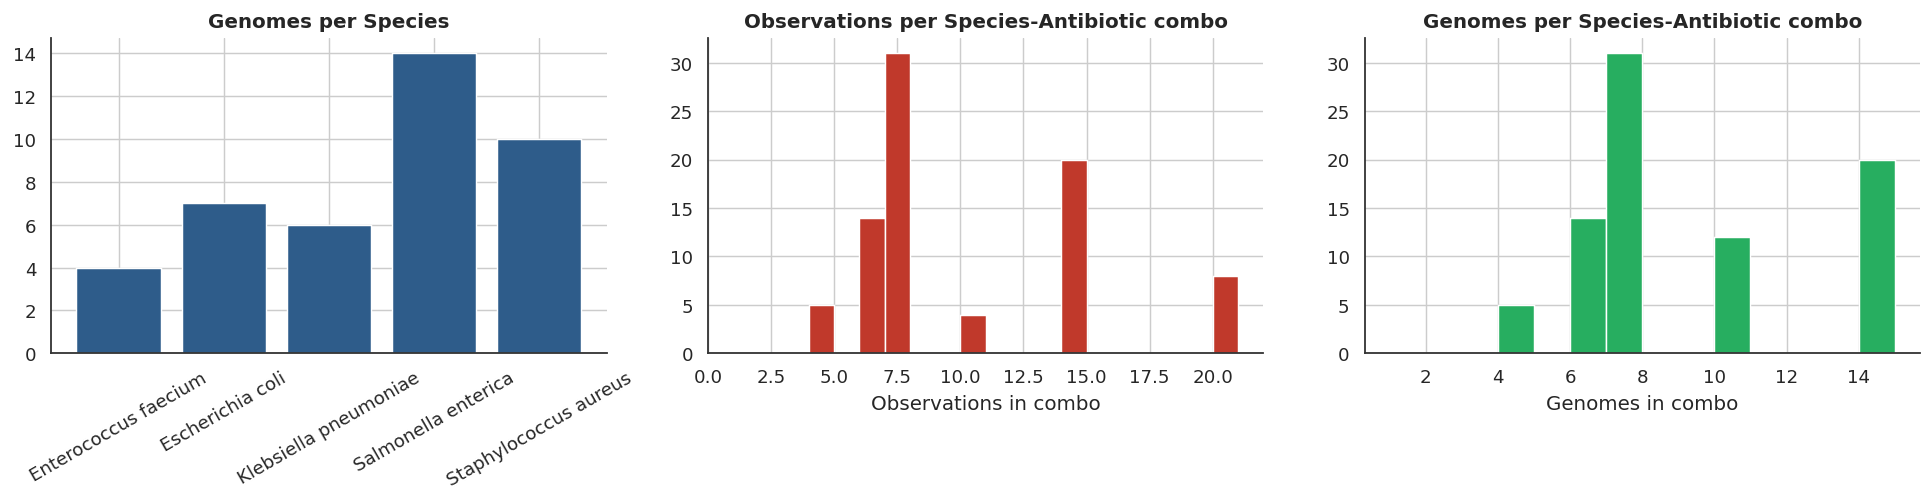

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(genomes_per_species.index, genomes_per_species.values, color=PALETTE["primary"])
axes[0].set_title("Genomes per Species", fontweight="bold"); axes[0].tick_params(axis='x', rotation=30)
axes[1].hist(obs_per_combo.values, bins=range(1, obs_per_combo.max()+2), color=PALETTE["secondary"], edgecolor='white')
axes[1].set_title("Observations per Species-Antibiotic combo", fontweight="bold")
axes[1].set_xlabel("Observations in combo")
axes[2].hist(genomes_per_combo.values, bins=range(1, genomes_per_combo.max()+2), color=PALETTE["tertiary"], edgecolor='white')
axes[2].set_title("Genomes per Species-Antibiotic combo", fontweight="bold")
axes[2].set_xlabel("Genomes in combo")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig0_dependency_structure.png", bbox_inches="tight")
plt.show()


---
# 6. Memorization Baselines

Before any machine-learning model is trained, we establish simple **lookup / majority-vote**
baselines. These quantify how much of the "predictive" signal in this dataset can be captured
by pure structural memorization — remembering the majority label observed for a group during
training — with no learned model at all.

**Leakage rule (strict):** every baseline below is fit using *only* the rows in the training
split it is given. For a test-time group never seen during training, the baseline falls back
to the *overall majority class of the training split* (documented explicitly). Test labels are
never used to compute any baseline's lookup table.

## 6a. Empirical Memorization Ceilings (descriptive dataset statistics)

These are **not** generalization estimates. They describe, in-sample, the best any
Species+Antibiotic-only (or Genome+Antibiotic-only) majority-vote rule could ever do on
*this exact labeled dataset*, given the label conflicts documented in Section 4d. They are
upper bounds implied by dataset structure, not achievable/expected out-of-sample accuracy.

In [ ]:
def in_sample_majority_ceiling(df, key_col, label_col='Resistant Phenotype'):
    """In-sample (descriptive) ceiling: weighted average of each group's majority-label share.
    NOT a leakage-safe generalization estimate -- see Section 6b for that."""
    per_group_majority_share = df.groupby(key_col)[label_col].apply(
        lambda g: g.value_counts(normalize=True).max())
    weights = df[key_col].value_counts()
    ceiling = (per_group_majority_share * weights).sum() / weights.sum()
    n_minority_rows = int(((1 - per_group_majority_share) * weights).sum())
    return ceiling, n_minority_rows

sa_ceiling, sa_minority_rows = in_sample_majority_ceiling(df, 'combo')
ga_ceiling, ga_minority_rows = in_sample_majority_ceiling(df, 'genome_antibiotic')

print(f"Species+Antibiotic majority-vote empirical ceiling (in-sample): {sa_ceiling:.4f}")
print(f"  -> {sa_minority_rows} / {len(df)} rows are the minority label within their own "
      f"Species+Antibiotic combo and can NEVER be predicted correctly by a Species+Antibiotic-only "
      f"majority rule, regardless of how well it 'memorizes'.")
print()
print(f"Genome+Antibiotic majority-vote empirical ceiling (in-sample): {ga_ceiling:.4f}")
print(f"  -> {ga_minority_rows} / {len(df)} rows are the minority label within their own "
      f"Genome+Antibiotic combo.")
print()
print("IMPORTANT: these numbers describe dataset structure (how internally consistent labels are "
      "within each grouping), NOT a maximum achievable model accuracy and NOT a biological limit. "
      "A model evaluated out-of-sample under a grouped regime (Sections 9-11) will generally score "
      "well below this ceiling, because unseen groups cannot be looked up at all.")

Species+Antibiotic majority-vote empirical ceiling (in-sample): 0.8602
  -> 112 / 801 rows are the minority label within their own Species+Antibiotic combo and can NEVER be predicted correctly by a Species+Antibiotic-only majority rule, regardless of how well it 'memorizes'.

Genome+Antibiotic majority-vote empirical ceiling (in-sample): 0.9850
  -> 12 / 801 rows are the minority label within their own Genome+Antibiotic combo.

IMPORTANT: these numbers describe dataset structure (how internally consistent labels are within each grouping), NOT a maximum achievable model accuracy and NOT a biological limit. A model evaluated out-of-sample under a grouped regime (Sections 9-11) will generally score well below this ceiling, because unseen groups cannot be looked up at all.


## 6b. Leakage-Safe Lookup Baselines (usable inside any evaluation regime)

These five baselines are implemented as reusable, `fit`/`predict`-style objects so that they can
be plugged into exactly the same train/test folds as the ML models in Sections 8-11, ensuring an
apples-to-apples comparison under identical splits.

In [ ]:
class GroupMajorityBaseline:
    """Leakage-safe majority-vote baseline keyed on one or more categorical columns.

    fit(X_train, y_train): builds a lookup table of the training-data majority label for each
        observed combination of `key_cols`, plus the overall training majority as a fallback.
    predict(X): looks up each row's key in the training-fit table; falls back to the overall
        training majority for any key never seen during training. Test labels are never touched.
    """
    def __init__(self, key_cols):
        self.key_cols = key_cols

    def fit(self, X, y):
        tmp = X[self.key_cols].copy()
        tmp['_y'] = np.asarray(y)
        self.fallback_ = int(pd.Series(y).mean() >= 0.5)
        if len(self.key_cols) == 1:
            self.lookup_ = tmp.groupby(self.key_cols[0])['_y'].apply(lambda s: int(s.mean() >= 0.5))
        else:
            self.lookup_ = tmp.groupby(self.key_cols)['_y'].apply(lambda s: int(s.mean() >= 0.5))
        return self

    def predict(self, X):
        if len(self.key_cols) == 1:
            keys = X[self.key_cols[0]]
            return keys.map(self.lookup_).fillna(self.fallback_).astype(int).values
        else:
            idx = pd.MultiIndex.from_frame(X[self.key_cols])
            mapped = idx.map(self.lookup_)
            return pd.Series(mapped, index=X.index).fillna(self.fallback_).astype(int).values

    def predict_proba(self, X):
        p1 = self.predict(X).astype(float)
        # Lookup baselines are hard-label rules; represent as a degenerate probability for
        # metrics (ROC/PR-AUC, Brier) that require a score. This is documented, not hidden.
        return np.column_stack([1 - p1, p1])


BASELINE_ZOO = {
    'Baseline: Overall Majority':        GroupMajorityBaseline([]),   # special-cased below
    'Baseline: Species Majority':        GroupMajorityBaseline(['Species']),
    'Baseline: Antibiotic Majority':     GroupMajorityBaseline(['Antibiotic']),
    'Baseline: Species+Antibiotic Majority': GroupMajorityBaseline(['Species', 'Antibiotic']),
    'Baseline: Genome+Antibiotic Majority':  GroupMajorityBaseline(['Genome ID', 'Antibiotic']),
}

class OverallMajorityBaseline(GroupMajorityBaseline):
    """Special case with no grouping key at all: always predicts the training majority class."""
    def __init__(self):
        super().__init__([])
    def fit(self, X, y):
        self.fallback_ = int(pd.Series(y).mean() >= 0.5)
        return self
    def predict(self, X):
        return np.full(len(X), self.fallback_)

BASELINE_ZOO['Baseline: Overall Majority'] = OverallMajorityBaseline()

logger.info("Defined %d leakage-safe memorization baselines: %s", len(BASELINE_ZOO), list(BASELINE_ZOO))


---
# 7. Feature Construction

## 7a. Antibiotic Class

`Antibiotic Class` is **not** a field present in the raw dataset. It is a manually curated
analytical grouping, built by mapping each antibiotic name to a standard pharmacological
class (e.g. beta-lactam, fluoroquinolone, aminoglycoside). It is **not** an authoritative
biological ontology field from BV-BRC, and is described as such everywhere it is used.

In [ ]:
ANTIBIOTIC_CLASS_MAP = {
    # Beta-lactams (penicillins)
    'ampicillin': 'Penicillin', 'amoxicillin': 'Penicillin', 'penicillin': 'Penicillin',
    'amoxicillin/clavulanic acid': 'Penicillin', 'ampicillin/sulbactam': 'Penicillin',
    'methicillin': 'Penicillin', 'oxacillin': 'Penicillin', 'piperacillin/tazobactam': 'Penicillin',
    # Cephalosporins
    'cefalothin': 'Cephalosporin', 'cefazolin': 'Cephalosporin', 'cefepime': 'Cephalosporin',
    'cefotaxime': 'Cephalosporin', 'cefoxitin': 'Cephalosporin', 'ceftazidime': 'Cephalosporin',
    'ceftiofur': 'Cephalosporin', 'ceftriaxone': 'Cephalosporin', 'cefuroxime': 'Cephalosporin',
    # Carbapenems / Monobactam
    'ertapenem': 'Carbapenem', 'imipenem': 'Carbapenem', 'meropenem': 'Carbapenem',
    'aztreonam': 'Monobactam',
    # Fluoroquinolones / quinolones
    'ciprofloxacin': 'Fluoroquinolone', 'levofloxacin': 'Fluoroquinolone',
    'norfloxacin': 'Fluoroquinolone', 'pefloxacin': 'Fluoroquinolone',
    'nalidixic acid': 'Quinolone',
    # Aminoglycosides
    'amikacin': 'Aminoglycoside', 'gentamicin': 'Aminoglycoside', 'kanamycin': 'Aminoglycoside',
    'streptomycin': 'Aminoglycoside', 'tobramycin': 'Aminoglycoside',
    # Macrolides / Lincosamide
    'azithromycin': 'Macrolide', 'erythromycin': 'Macrolide', 'clindamycin': 'Lincosamide',
    # Tetracyclines
    'doxycycline': 'Tetracycline', 'tetracycline': 'Tetracycline',
    # Glycopeptide / Lipopeptide / Oxazolidinone / Fusidane / Aminocyclitol
    'vancomycin': 'Glycopeptide', 'daptomycin': 'Lipopeptide', 'linezolid': 'Oxazolidinone',
    'fusidic acid': 'Fusidane', 'spectinomycin': 'Aminocyclitol',
    # Sulfonamides / folate-pathway inhibitors
    'sulfamethoxazole': 'Sulfonamide', 'sulfisoxazole': 'Sulfonamide',
    'trimethoprim': 'Folate inhibitor', 'trimethoprim/sulfamethoxazole': 'Folate inhibitor',
    # Amphenicol
    'chloramphenicol': 'Amphenicol',
}
# Source: this is a standard pharmacological classification of antibiotic mechanism/family
# (comparable to WHO ATC / CLSI antibiotic groupings), curated manually for this analysis.
# It is NOT provided by BV-BRC and should not be cited as dataset-native metadata.

df['Antibiotic_Lower'] = df['Antibiotic'].str.lower().str.strip()
df['Antibiotic_Class'] = df['Antibiotic_Lower'].map(ANTIBIOTIC_CLASS_MAP).fillna('Other')

n_mapped_abx = df['Antibiotic_Lower'].isin(ANTIBIOTIC_CLASS_MAP).sum()
n_unmapped_abx = (df['Antibiotic_Class'] == 'Other').sum()
antibiotics_total = df['Antibiotic'].nunique()
antibiotics_mapped = df.loc[df['Antibiotic_Class'] != 'Other', 'Antibiotic'].nunique()

logger.info("Antibiotic-class mapping: %d / %d unique antibiotics mapped (%d unique antibiotics unmapped -> 'Other')",
            antibiotics_mapped, antibiotics_total, antibiotics_total - antibiotics_mapped)
logger.info("Rows: %d / %d (%.1f%%) fall into a named class; %d rows (%.1f%%) fall into 'Other'",
            n_mapped_abx, len(df), n_mapped_abx/len(df)*100, n_unmapped_abx, n_unmapped_abx/len(df)*100)

df.groupby('Antibiotic_Class')['Antibiotic'].apply(lambda s: sorted(s.unique())).to_frame('antibiotics_in_class')


,antibiotics_in_class
Antibiotic_Class,
Aminocyclitol,[spectinomycin]
Aminoglycoside,"[amikacin, gentamicin, kanamycin, streptomycin..."
Amphenicol,[chloramphenicol]
Carbapenem,"[ertapenem, imipenem, meropenem]"
Cephalosporin,"[cefalothin, cefazolin, cefepime, cefotaxime, ..."
Fluoroquinolone,"[ciprofloxacin, levofloxacin, norfloxacin, pef..."
Folate inhibitor,"[trimethoprim, trimethoprim/sulfamethoxazole]"
Fusidane,[fusidic acid]
Glycopeptide,[vancomycin]


## 7b. Feature Encoding

Categorical metadata (Species, Antibiotic, Antibiotic_Class, Computational Method) is
one-hot encoded rather than integer/label encoded. Integer codes would impose a spurious
ordinal relationship (e.g. implying `S. aureus` is "greater than" `E. coli`), which none of
these fields actually have.

**Leakage safety.** The encoder is never fit on the full dataset up front. It is wrapped in a
`sklearn.pipeline.Pipeline` together with the classifier and is re-fit *inside every training
fold only*, for every evaluation regime in Sections 9-13. `OneHotEncoder(handle_unknown="ignore")`
ensures that a category value appearing only in a held-out fold (e.g. under
Leave-One-Species-Out) is handled safely rather than crashing or leaking test information back
into encoding.

In [ ]:
FEATURES_FULL = ['Species', 'Antibiotic', 'Antibiotic_Class', 'Computational Method']
FEATURES_NO_COMPMETHOD = ['Species', 'Antibiotic', 'Antibiotic_Class']
LOSO_FEATURES = ['Antibiotic', 'Antibiotic_Class']  # Species excluded: it IS the held-out variable

TARGET_COL = 'Resistant Phenotype'
y_all = (df[TARGET_COL] == 'Resistant').astype(int).values  # 1 = Resistant, 0 = Susceptible
logger.info("Encoded target: 1='Resistant' (n=%d), 0='Susceptible' (n=%d)",
            (y_all==1).sum(), (y_all==0).sum())

def make_pipeline(model, cat_cols):
    """Leakage-safe pipeline: one-hot encoding fit ONLY on the data passed to .fit()."""
    ct = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])
    return Pipeline([('prep', ct), ('clf', model)])


---
# 8. Machine-Learning Models

Per Sections 17-18 of the project brief, the model set is deliberately small and controlled:
one linear model and three tree-ensemble models, all with reasonable, mostly-default
hyperparameters. No hyperparameter search is run against any held-out fold — the parameters
below are fixed in advance and documented here rather than tuned against test performance.
This is a controlled comparison of evaluation regimes, not a model competition.

In [ ]:
def get_model_zoo(seed: int = SEED) -> dict:
    """Fixed, lightly-configured model set. No test-set-driven tuning anywhere in this notebook."""
    return {
        'Logistic Regression': LogisticRegression(max_iter=2000, random_state=seed),
        'Random Forest': RandomForestClassifier(n_estimators=300, random_state=seed),
        'Gradient Boosting': GradientBoostingClassifier(random_state=seed),
        'XGBoost': xgb.XGBClassifier(eval_metric='logloss', random_state=seed, verbosity=0),
    }

REAL_MODEL_NAMES = ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']
MODEL_HYPERPARAMS = pd.DataFrame([
    dict(model='Logistic Regression', key_params='max_iter=2000 (convergence only, not tuned), default L2, C=1.0'),
    dict(model='Random Forest', key_params='n_estimators=300, other params scikit-learn default'),
    dict(model='Gradient Boosting', key_params='scikit-learn default (n_estimators=100, learning_rate=0.1, max_depth=3)'),
    dict(model='XGBoost', key_params='eval_metric=logloss, other params xgboost default'),
])
MODEL_HYPERPARAMS


,model,key_params
0,Logistic Regression,"max_iter=2000 (convergence only, not tuned), d..."
1,Random Forest,"n_estimators=300, other params scikit-learn de..."
2,Gradient Boosting,"scikit-learn default (n_estimators=100, learni..."
3,XGBoost,"eval_metric=logloss, other params xgboost default"


---
# 9. Evaluation Framework

This section implements the four evaluation regimes as reusable functions. Every regime:

1. Builds train/test folds according to its grouping rule.
2. Fits the one-hot encoder **and** every model/baseline *only* on that fold's training rows.
3. Scores on that fold's held-out rows.
4. Records fold-level metrics for later aggregation (Section 11) and fold-level group
   membership for the split-integrity audit (Section 10).

`compute_metrics()` is the single shared scoring function used everywhere in the notebook, so
that every regime and every model is scored identically.

In [ ]:
def compute_metrics(y_true, y_pred, y_proba):
    """Shared metric computation used by every evaluation regime and every model."""
    out = dict(
        n_test=len(y_true),
        accuracy=accuracy_score(y_true, y_pred),
        balanced_accuracy=balanced_accuracy_score(y_true, y_pred),
        f1=f1_score(y_true, y_pred, zero_division=0),
        sensitivity=recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        specificity=recall_score(y_true, y_pred, pos_label=0, zero_division=0),
    )
    if len(np.unique(y_true)) > 1:
        out['roc_auc'] = roc_auc_score(y_true, y_proba)
        out['pr_auc'] = average_precision_score(y_true, y_proba)
        out['brier'] = brier_score_loss(y_true, y_proba)
    else:
        # A fold with only one true class present cannot support ROC/PR-AUC -- reported as NaN,
        # not silently omitted, and explained wherever it occurs (e.g. small LOSO folds).
        out['roc_auc'] = np.nan
        out['pr_auc'] = np.nan
        out['brier'] = brier_score_loss(y_true, y_proba)
    return out


def overlap_counts(df, tr_idx, te_idx):
    """Split-integrity audit: how many Species / Genome / S-A / Genome-Antibiotic values in the
    test fold also appear in the training fold, for ANY grouping (used regardless of which
    grouping the fold was actually built on)."""
    tr, te = df.iloc[tr_idx], df.iloc[te_idx]
    def frac_overlap(col):
        te_vals = set(te[col].unique())
        if len(te_vals) == 0:
            return 0, 0
        overlap = len(te_vals & set(tr[col].unique()))
        return overlap, len(te_vals)
    sp_ov, sp_tot = frac_overlap('Species')
    gn_ov, gn_tot = frac_overlap('Genome ID')
    sa_ov, sa_tot = frac_overlap('combo')
    ga_ov, ga_tot = frac_overlap('genome_antibiotic')
    return dict(species_overlap=sp_ov, species_total=sp_tot,
                genome_overlap=gn_ov, genome_total=gn_tot,
                sa_overlap=sa_ov, sa_total=sa_tot,
                ga_overlap=ga_ov, ga_total=ga_tot,
                n_train=len(tr_idx), n_test=len(te_idx))


def run_regime(df, y, feature_cols, splitter_fn, regime_name, models=None, seed=SEED,
               include_baselines=True):
    """Run one evaluation regime across all folds, all ML models, and (optionally) all
    memorization baselines. Returns (fold_metrics_df, overlap_df, per_fold_predictions).

    `splitter_fn(df, y)` must yield (train_idx, test_idx) pairs (positional integer indices
    into `df`/`y`).
    """
    if models is None:
        models = get_model_zoo(seed)
    all_rows = []
    overlap_rows = []
    predictions = []  # (fold_id, model_name, test_idx, y_true, y_pred, y_proba)

    for fold_id, (tr_idx, te_idx) in enumerate(splitter_fn(df, y)):
        Xtr_raw, Xte_raw = df.iloc[tr_idx], df.iloc[te_idx]
        ytr, yte = y[tr_idx], y[te_idx]

        ov = overlap_counts(df, tr_idx, te_idx)
        ov['fold'] = fold_id
        overlap_rows.append(ov)

        model_set = dict(models)
        if include_baselines:
            model_set.update({k: v for k, v in BASELINE_ZOO.items()})

        for name, model in model_set.items():
            if name.startswith('Baseline:'):
                bl = type(model)(*([model.key_cols] if hasattr(model, 'key_cols') and model.key_cols else []))
                bl.fit(Xtr_raw, ytr)
                pred = bl.predict(Xte_raw)
                proba = bl.predict_proba(Xte_raw)[:, 1]
            else:
                pipe = make_pipeline(model, feature_cols)
                pipe.fit(Xtr_raw[feature_cols], ytr)
                pred = pipe.predict(Xte_raw[feature_cols])
                proba = pipe.predict_proba(Xte_raw[feature_cols])[:, 1]

            m = compute_metrics(yte, pred, proba)
            m.update(regime=regime_name, model=name, fold=fold_id)
            all_rows.append(m)
            predictions.append((fold_id, name, te_idx, yte, pred, proba))

    return pd.DataFrame(all_rows), pd.DataFrame(overlap_rows), predictions


# --- Splitter functions for the four regimes -------------------------------------------
def split_random(df, y, seed=SEED, n_splits=N_SPLITS_GROUPED):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr, te in skf.split(df, y):
        yield tr, te

def split_unseen_sa(df, y, n_splits=N_SPLITS_GROUPED):
    gkf = GroupKFold(n_splits=n_splits)
    for tr, te in gkf.split(df, y, groups=df['combo'].values):
        yield tr, te

def split_unseen_genome(df, y, n_splits=N_SPLITS_GROUPED):
    gkf = GroupKFold(n_splits=n_splits)
    for tr, te in gkf.split(df, y, groups=df['Genome ID'].values):
        yield tr, te

def split_loso(df, y):
    logo = LeaveOneGroupOut()
    for tr, te in logo.split(df, y, groups=df['Species'].values):
        yield tr, te

logger.info("Evaluation framework defined: 4 regime splitters, shared compute_metrics(), "
            "shared overlap_counts() for the split-integrity audit, and run_regime() which "
            "fits encoding+model fresh inside every training fold only.")

---
# 10. Split Integrity Audit

Rather than assuming each splitter behaves as intended, we run all four regimes now and
directly measure, fold by fold, how many Species / Genome / Species-Antibiotic /
Genome-Antibiotic values in the test set also occur in the training set. This is computed
identically regardless of which key the splitter actually grouped on, so we can see exactly
which overlaps survive and which do not.

In [ ]:
def compute_metrics(y_true, y_pred, y_proba):
    """Shared metric computation used by every evaluation regime and every model."""
    out = dict(
        n_test=len(y_true),
        accuracy=accuracy_score(y_true, y_pred),
        balanced_accuracy=balanced_accuracy_score(y_true, y_pred),
        f1=f1_score(y_true, y_pred, zero_division=0),
        sensitivity=recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        specificity=recall_score(y_true, y_pred, pos_label=0, zero_division=0),
    )
    if len(np.unique(y_true)) > 1:
        out['roc_auc'] = roc_auc_score(y_true, y_proba)
        out['pr_auc'] = average_precision_score(y_true, y_proba)
        out['brier'] = brier_score_loss(y_true, y_proba)
    else:
        # A fold with only one true class present cannot support ROC/PR-AUC -- reported as NaN,
        # not silently omitted, and explained wherever it occurs (e.g. small LOSO folds).
        out['roc_auc'] = np.nan
        out['pr_auc'] = np.nan
        out['brier'] = brier_score_loss(y_true, y_proba)
    return out


def overlap_counts(df, tr_idx, te_idx):
    """Split-integrity audit: how many Species / Genome / S-A / Genome-Antibiotic values in the
    test fold also appear in the training fold, for ANY grouping (used regardless of which
    grouping the fold was actually built on)."""
    tr, te = df.iloc[tr_idx], df.iloc[te_idx]
    def frac_overlap(col):
        te_vals = set(te[col].unique())
        if len(te_vals) == 0:
            return 0, 0
        overlap = len(te_vals & set(tr[col].unique()))
        return overlap, len(te_vals)
    sp_ov, sp_tot = frac_overlap('Species')
    gn_ov, gn_tot = frac_overlap('Genome ID')
    sa_ov, sa_tot = frac_overlap('combo')
    ga_ov, ga_tot = frac_overlap('genome_antibiotic')
    return dict(species_overlap=sp_ov, species_total=sp_tot,
                genome_overlap=gn_ov, genome_total=gn_tot,
                sa_overlap=sa_ov, sa_total=sa_tot,
                ga_overlap=ga_ov, ga_total=ga_tot,
                n_train=len(tr_idx), n_test=len(te_idx))


def run_regime(df, y, feature_cols, splitter_fn, regime_name, models=None, seed=SEED,
               include_baselines=True):
    """Run one evaluation regime across all folds, all ML models, and (optionally) all
    memorization baselines. Returns (fold_metrics_df, overlap_df, per_fold_predictions).

    `splitter_fn(df, y)` must yield (train_idx, test_idx) pairs (positional integer indices
    into `df`/`y`).
    """
    if models is None:
        models = get_model_zoo(seed)
    all_rows = []
    overlap_rows = []
    predictions = []  # (fold_id, model_name, test_idx, y_true, y_pred, y_proba)

    for fold_id, (tr_idx, te_idx) in enumerate(splitter_fn(df, y)):
        Xtr_raw, Xte_raw = df.iloc[tr_idx], df.iloc[te_idx]
        ytr, yte = y[tr_idx], y[te_idx]

        ov = overlap_counts(df, tr_idx, te_idx)
        ov['fold'] = fold_id
        overlap_rows.append(ov)

        model_set = dict(models)
        if include_baselines:
            model_set.update({k: v for k, v in BASELINE_ZOO.items()})

        for name, model in model_set.items():
            if name.startswith('Baseline:'):
                bl = type(model)(*([model.key_cols] if hasattr(model, 'key_cols') and model.key_cols else []))
                bl.fit(Xtr_raw, ytr)
                pred = bl.predict(Xte_raw)
                proba = bl.predict_proba(Xte_raw)[:, 1]
            else:
                pipe = make_pipeline(model, feature_cols)
                pipe.fit(Xtr_raw[feature_cols], ytr)
                pred = pipe.predict(Xte_raw[feature_cols])
                proba = pipe.predict_proba(Xte_raw[feature_cols])[:, 1]

            m = compute_metrics(yte, pred, proba)
            m.update(regime=regime_name, model=name, fold=fold_id)
            all_rows.append(m)
            predictions.append((fold_id, name, te_idx, yte, pred, proba))

    return pd.DataFrame(all_rows), pd.DataFrame(overlap_rows), predictions


# --- Splitter functions for the four regimes -------------------------------------------
def split_random(df, y, seed=SEED, n_splits=N_SPLITS_GROUPED):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr, te in skf.split(df, y):
        yield tr, te

def split_unseen_sa(df, y, n_splits=N_SPLITS_GROUPED):
    gkf = GroupKFold(n_splits=n_splits)
    for tr, te in gkf.split(df, y, groups=df['combo'].values):
        yield tr, te

def split_unseen_genome(df, y, n_splits=N_SPLITS_GROUPED):
    gkf = GroupKFold(n_splits=n_splits)
    for tr, te in gkf.split(df, y, groups=df['Genome ID'].values):
        yield tr, te

def split_loso(df, y):
    logo = LeaveOneGroupOut()
    for tr, te in logo.split(df, y, groups=df['Species'].values):
        yield tr, te

logger.info("Running Regime 1: Random row-level split (%d-fold, stratified)...", N_SPLITS_GROUPED)
metrics_random, overlap_random, preds_random = run_regime(
    df, y_all, FEATURES_FULL, split_random, "Random row-level")

logger.info("Running Regime 2: Unseen Species-Antibiotic (GroupKFold on combo)...")
metrics_sa, overlap_sa, preds_sa = run_regime(
    df, y_all, FEATURES_FULL, split_unseen_sa, "Unseen Species-Antibiotic")

logger.info("Running Regime 3: Unseen Genome (GroupKFold on Genome ID)...")
metrics_genome, overlap_genome, preds_genome = run_regime(
    df, y_all, FEATURES_FULL, split_unseen_genome, "Unseen Genome")

logger.info("Running Regime 4: Leave-One-Species-Out (Species excluded from features)...")
metrics_loso, overlap_loso, preds_loso = run_regime(
    df, y_all, LOSO_FEATURES, split_loso, "Leave-One-Species-Out")

ALL_METRICS = pd.concat([metrics_random, metrics_sa, metrics_genome, metrics_loso], ignore_index=True)
ALL_OVERLAPS = {
    "Random row-level": overlap_random, "Unseen Species-Antibiotic": overlap_sa,
    "Unseen Genome": overlap_genome, "Leave-One-Species-Out": overlap_loso,
}
logger.info("All four regimes complete. Total fold x model result rows: %d", len(ALL_METRICS))

In [ ]:
def summarize_overlap(regime_name, ov_df):
    return dict(
        regime=regime_name,
        mean_train_rows=ov_df['n_train'].mean(), mean_test_rows=ov_df['n_test'].mean(),
        species_overlap_pct=(ov_df['species_overlap'].sum() / ov_df['species_total'].sum() * 100),
        genome_overlap_pct=(ov_df['genome_overlap'].sum() / ov_df['genome_total'].sum() * 100),
        sa_overlap_pct=(ov_df['sa_overlap'].sum() / ov_df['sa_total'].sum() * 100),
        ga_overlap_pct=(ov_df['ga_overlap'].sum() / ov_df['ga_total'].sum() * 100),
    )

split_integrity_table = pd.DataFrame([summarize_overlap(name, ov) for name, ov in ALL_OVERLAPS.items()]).round(1)
split_integrity_table.columns = ['Regime', 'Mean train rows', 'Mean test rows',
                                  'Species overlap %', 'Genome overlap %',
                                  'S-A overlap %', 'Genome-Antibiotic overlap %']
split_integrity_table


,Regime,Mean train rows,Mean test rows,Species overlap %,Genome overlap %,S-A overlap %,Genome-Antibiotic overlap %
0,Random row-level,640.8,160.2,100.0,100.0,100.0,16.3
1,Unseen Species-Antibiotic,640.8,160.2,100.0,100.0,0.0,0.0
2,Unseen Genome,640.8,160.2,100.0,0.0,100.0,0.0
3,Leave-One-Species-Out,640.8,160.2,0.0,0.0,0.0,0.0


**Reading this table.** "Overlap %" is the percentage of *test-set* values (of that key)
in an *average* fold that also appear somewhere in that fold's training set. The values are
reported as computed — we do not force the expected pattern (Section 20 of the brief). Any
departure from the expected conceptual structure (e.g. Species-Antibiotic overlap not exactly
0% under the Unseen Species-Antibiotic regime) would indicate a bug and is checked next.

In [ ]:
# Hard assertions: the regime's OWN grouping key must show exactly 0% overlap by construction.
assert overlap_sa['sa_overlap'].sum() == 0, "Species-Antibiotic leaked across folds under Regime 2!"
assert overlap_genome['genome_overlap'].sum() == 0, "Genome leaked across folds under Regime 3!"
assert overlap_loso['species_overlap'].sum() == 0, "Species leaked across folds under Regime 4 (LOSO)!"
logger.info("Split-integrity assertions passed: each regime's own grouping key never overlaps "
            "between train and test, exactly as required for that regime to be valid.")

---
# 11. Main Results

## 11a. Master Table: Evaluation Regime x Model

Mean ± standard deviation across the folds of each regime (5 folds for regimes 1-3, one
fold per species for regime 4). This is the central table of the notebook: the comparison
that matters is **across regimes for a given model**, not which model "wins" within a regime.

In [ ]:
def summarize_metrics(metrics_df):
    agg_cols = ['accuracy', 'balanced_accuracy', 'f1', 'roc_auc', 'pr_auc',
                'sensitivity', 'specificity', 'brier']
    g = metrics_df.groupby(['regime', 'model'])[agg_cols].agg(['mean', 'std'])
    g.columns = [f"{c}_{stat}" for c, stat in g.columns]
    return g.reset_index()

MAIN_RESULTS = summarize_metrics(ALL_METRICS)
regime_order = ["Random row-level", "Unseen Species-Antibiotic", "Unseen Genome", "Leave-One-Species-Out"]
MAIN_RESULTS['regime'] = pd.Categorical(MAIN_RESULTS['regime'], categories=regime_order, ordered=True)
MAIN_RESULTS = MAIN_RESULTS.sort_values(['regime', 'model']).reset_index(drop=True)

display_cols = ['regime', 'model', 'accuracy_mean', 'accuracy_std', 'balanced_accuracy_mean',
                 'f1_mean', 'roc_auc_mean', 'pr_auc_mean', 'sensitivity_mean', 'specificity_mean']
MAIN_RESULTS[display_cols].round(3)


,regime,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,f1_mean,roc_auc_mean,pr_auc_mean,sensitivity_mean,specificity_mean
0,Random row-level,Baseline: Antibiotic Majority,0.704,0.036,0.704,0.690,0.704,0.648,0.665,0.743
1,Random row-level,Baseline: Genome+Antibiotic Majority,0.546,0.017,0.546,0.284,0.546,0.533,0.275,0.817
2,Random row-level,Baseline: Overall Majority,0.499,0.001,0.500,0.133,0.500,0.499,0.200,0.800
3,Random row-level,Baseline: Species Majority,0.679,0.033,0.679,0.654,0.679,0.629,0.628,0.731
4,Random row-level,Baseline: Species+Antibiotic Majority,0.838,0.028,0.838,0.844,0.838,0.775,0.880,0.795
5,Random row-level,Gradient Boosting,0.824,0.023,0.824,0.820,0.898,0.858,0.807,0.840
6,Random row-level,Logistic Regression,0.830,0.025,0.830,0.828,0.881,0.828,0.820,0.840
7,Random row-level,Random Forest,0.851,0.033,0.851,0.856,0.902,0.862,0.885,0.818
8,Random row-level,XGBoost,0.844,0.028,0.844,0.849,0.902,0.874,0.882,0.805
9,Unseen Species-Antibiotic,Baseline: Antibiotic Majority,0.392,0.091,0.448,0.430,0.448,0.480,0.561,0.335


## 11b. Group-Aware Bootstrap Confidence Intervals

For grouped regimes, resampling individual rows would understate uncertainty (rows within
the same group are not independent). Instead we resample **groups** with replacement —
Species-Antibiotic combinations for the S-A regime, genomes for the Genome regime — refit
nothing, and simply recompute accuracy on the resampled set of already-collected fold
predictions. For the random row-level regime, ordinary row bootstrap is appropriate since
rows there are the evaluation unit. Because Leave-One-Species-Out has only 5 groups total,
a bootstrap interval over species would be unreliable; we report that limitation instead of
a falsely precise interval.

In [ ]:
def bootstrap_ci_rows(y_true, y_pred, n_boot=N_BOOTSTRAP, seed=SEED):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    accs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        accs.append(accuracy_score(np.asarray(y_true)[idx], np.asarray(y_pred)[idx]))
    return np.percentile(accs, [2.5, 97.5])

def bootstrap_ci_groups(predictions_for_model, group_ids, n_boot=N_BOOTSTRAP, seed=SEED):
    """Cluster bootstrap: resample unique groups with replacement, pool all rows belonging to
    the resampled groups, recompute accuracy. `predictions_for_model` is a DataFrame with
    columns ['group', 'y_true', 'y_pred'] pooled across all folds of one regime/model."""
    rng = np.random.RandomState(seed)
    unique_groups = np.array(sorted(set(group_ids)))
    accs = []
    for _ in range(n_boot):
        sampled_groups = rng.choice(unique_groups, size=len(unique_groups), replace=True)
        rows = predictions_for_model[predictions_for_model['group'].isin(set(sampled_groups))]
        # weight by how many times each group was drawn, to respect the resample properly
        parts = []
        for g in sampled_groups:
            parts.append(predictions_for_model[predictions_for_model['group'] == g])
        pooled = pd.concat(parts, ignore_index=True) if parts else predictions_for_model.iloc[0:0]
        if len(pooled) == 0:
            continue
        accs.append(accuracy_score(pooled['y_true'], pooled['y_pred']))
    return np.percentile(accs, [2.5, 97.5]) if accs else (np.nan, np.nan)

def pool_predictions(preds_list, group_key_fn):
    rows = []
    for fold_id, model_name, te_idx, yte, pred, proba in preds_list:
        grp = group_key_fn(te_idx)
        for g, yt, yp in zip(grp, yte, pred):
            rows.append(dict(model=model_name, group=g, y_true=yt, y_pred=yp))
    return pd.DataFrame(rows)

# Random regime: row bootstrap (evaluation unit = row) -- use one representative model
gb_random_pred = [p for p in preds_random if p[1] == 'Gradient Boosting']
yte_all = np.concatenate([p[3] for p in gb_random_pred])
pred_all = np.concatenate([p[4] for p in gb_random_pred])
ci_random = bootstrap_ci_rows(yte_all, pred_all)

# S-A regime: cluster bootstrap over Species-Antibiotic groups
pooled_sa = pool_predictions([p for p in preds_sa if p[1] == 'Gradient Boosting'],
                              lambda idx: df.iloc[idx]['combo'].values)
ci_sa = bootstrap_ci_groups(pooled_sa, pooled_sa['group'])

# Genome regime: cluster bootstrap over genomes
pooled_genome = pool_predictions([p for p in preds_genome if p[1] == 'Gradient Boosting'],
                                  lambda idx: df.iloc[idx]['Genome ID'].values)
ci_genome = bootstrap_ci_groups(pooled_genome, pooled_genome['group'])

ci_table = pd.DataFrame([
    dict(regime="Random row-level", bootstrap_unit="row", n_units=len(yte_all),
         accuracy_95ci_low=ci_random[0], accuracy_95ci_high=ci_random[1]),
    dict(regime="Unseen Species-Antibiotic", bootstrap_unit="S-A group",
         n_units=pooled_sa['group'].nunique(), accuracy_95ci_low=ci_sa[0], accuracy_95ci_high=ci_sa[1]),
    dict(regime="Unseen Genome", bootstrap_unit="genome",
         n_units=pooled_genome['group'].nunique(), accuracy_95ci_low=ci_genome[0], accuracy_95ci_high=ci_genome[1]),
    dict(regime="Leave-One-Species-Out", bootstrap_unit="species (only 5 groups)",
         n_units=5, accuracy_95ci_low=np.nan, accuracy_95ci_high=np.nan),
]).round(3)
print("95% bootstrap confidence intervals for accuracy, Gradient Boosting, full feature set:")
print("(LOSO interval intentionally left blank: only 5 groups is too few for a reliable "
      "group-cluster bootstrap; the 5 individual per-species results in Section 9's LOSO run "
      "are reported directly instead.)")
ci_table


95% bootstrap confidence intervals for accuracy, Gradient Boosting, full feature set:
(LOSO interval intentionally left blank: only 5 groups is too few for a reliable group-cluster bootstrap; the 5 individual per-species results in Section 9's LOSO run are reported directly instead.)


,regime,bootstrap_unit,n_units,accuracy_95ci_low,accuracy_95ci_high
0,Random row-level,row,801,0.798,0.849
1,Unseen Species-Antibiotic,S-A group,82,0.540,0.715
2,Unseen Genome,genome,41,0.753,0.884
3,Leave-One-Species-Out,species (only 5 groups),5,NaN,NaN


## 11c. Performance-Drop Analysis Across Regimes

In [ ]:
gb_summary = MAIN_RESULTS[MAIN_RESULTS['model'] == 'Gradient Boosting'].set_index('regime')['accuracy_mean']
drop_table = pd.DataFrame({
    'transition': ['Random -> Unseen S-A', 'Unseen S-A -> Unseen Genome', 'Unseen Genome -> LOSO'],
    'accuracy_before': [gb_summary['Random row-level'], gb_summary['Unseen Species-Antibiotic'],
                         gb_summary['Unseen Genome']],
    'accuracy_after': [gb_summary['Unseen Species-Antibiotic'], gb_summary['Unseen Genome'],
                        gb_summary['Leave-One-Species-Out']],
})
drop_table['change_pp'] = (drop_table['accuracy_after'] - drop_table['accuracy_before']) * 100
drop_table.round(3)


,transition,accuracy_before,accuracy_after,change_pp
0,Random -> Unseen S-A,0.824,0.628,-19.593
1,Unseen S-A -> Unseen Genome,0.628,0.824,19.580
2,Unseen Genome -> LOSO,0.824,0.438,-38.593


**Interpretation.** These transitions are not expected to be monotonic, because each
regime controls a *different* axis of overlap (Section 1). A drop from Random to Unseen S-A
reflects loss of the ability to memorize a previously-seen Species-Antibiotic relationship.
A change from Unseen S-A to Unseen Genome reflects a different, not strictly "harder", axis:
Unseen Genome still allows familiar Species-Antibiotic relationships (Section 10 confirms
S-A overlap is not systematically 0% there), so it is not guaranteed to score lower than
Unseen S-A. Whatever the actual computed direction of change is here, it should be read as
evidence about *which kind of overlap this model depends on*, not as evidence of a strictly
ordered difficulty scale. LOSO, with only 5 held-out groups, is treated as a small-sample
exploratory result rather than a stable point estimate.

/tmp/ipykernel_921/1289895424.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(regime_order, rotation=15, ha='right')


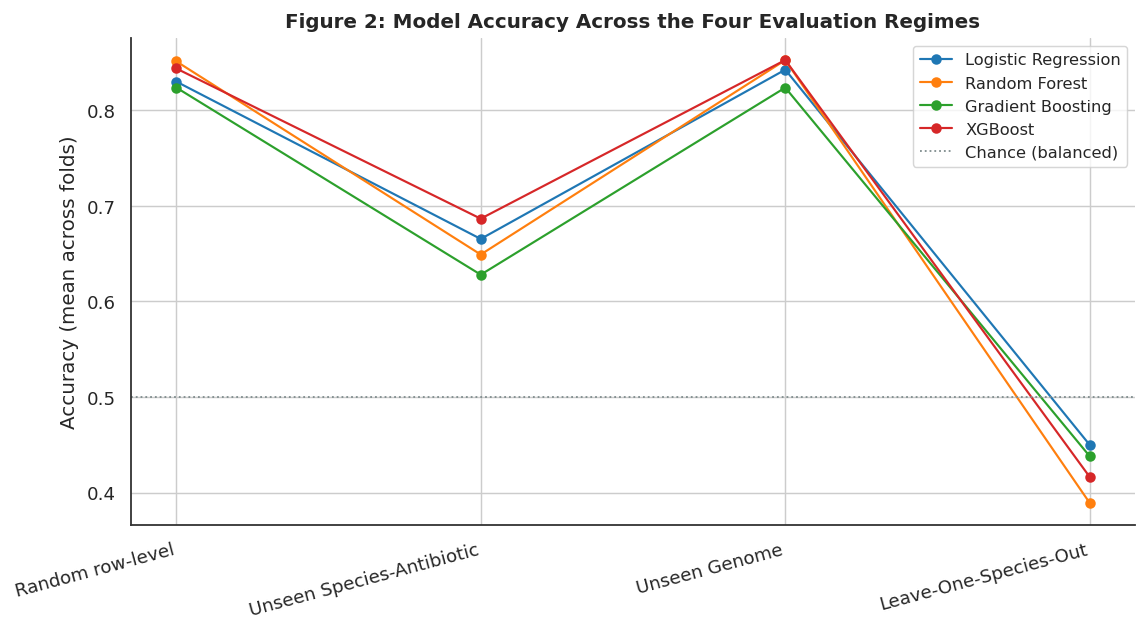

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = MAIN_RESULTS[MAIN_RESULTS['model'].isin(REAL_MODEL_NAMES)].copy()
for model_name in REAL_MODEL_NAMES:
    sub = plot_df[plot_df['model'] == model_name].sort_values('regime')
    ax.plot(sub['regime'].astype(str), sub['accuracy_mean'], marker='o', label=model_name)
ax.set_ylabel('Accuracy (mean across folds)')
ax.set_title('Figure 2: Model Accuracy Across the Four Evaluation Regimes', fontweight='bold')
ax.set_xticklabels(regime_order, rotation=15, ha='right')
ax.axhline(0.5, linestyle=':', color=PALETTE['neutral'], linewidth=1, label='Chance (balanced)')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure2_regime_comparison.png", bbox_inches="tight")
plt.show()


---
# 12. Feature Ablation

Which information is actually driving predictive performance? We evaluate progressively
richer feature subsets under the **Unseen Genome** regime (chosen as the primary ablation
regime because it is the strictest regime in which `Species` and `Antibiotic` remain usable
features — LOSO cannot use Species at all, and Unseen S-A would trivially penalize any
Species+Antibiotic-based feature set by construction). Gradient Boosting is used as the
representative model, consistent with its use elsewhere in the notebook as the default
model for single-model diagnostics.

In [ ]:
ablation_feature_sets = {
    'Species only': ['Species'],
    'Antibiotic only': ['Antibiotic'],
    'Antibiotic_Class only': ['Antibiotic_Class'],
    'Species + Antibiotic': ['Species', 'Antibiotic'],
    'Species + Antibiotic + Antibiotic_Class': ['Species', 'Antibiotic', 'Antibiotic_Class'],
    'Full feature set (+ Computational Method)': FEATURES_FULL,
    'Full minus Computational Method': FEATURES_NO_COMPMETHOD,
}

ablation_rows = []
for name, cols in ablation_feature_sets.items():
    m, _, _ = run_regime(df, y_all, cols, split_unseen_genome,
                          f"Unseen Genome | {name}", models={'Gradient Boosting': GradientBoostingClassifier(random_state=SEED)},
                          include_baselines=False)
    ablation_rows.append(dict(
        feature_set=name, n_features=len(cols),
        accuracy_mean=m['accuracy'].mean(), accuracy_std=m['accuracy'].std(),
        f1_mean=m['f1'].mean(), roc_auc_mean=m['roc_auc'].mean(),
    ))

ablation_table = pd.DataFrame(ablation_rows).round(3)
overall_majority_baseline = pd.Series(y_all).value_counts(normalize=True).max()
logger.info("Overall labeled-data majority-class baseline for reference: %.3f", overall_majority_baseline)
ablation_table

,feature_set,n_features,accuracy_mean,accuracy_std,f1_mean,roc_auc_mean
0,Species only,1,0.672,0.061,0.656,0.743
1,Antibiotic only,1,0.674,0.052,0.679,0.807
2,Antibiotic_Class only,1,0.649,0.064,0.675,0.712
3,Species + Antibiotic,2,0.821,0.079,0.807,0.887
4,Species + Antibiotic + Antibiotic_Class,3,0.828,0.083,0.818,0.892
5,Full feature set (+ Computational Method),4,0.824,0.081,0.813,0.893
6,Full minus Computational Method,3,0.828,0.083,0.818,0.892


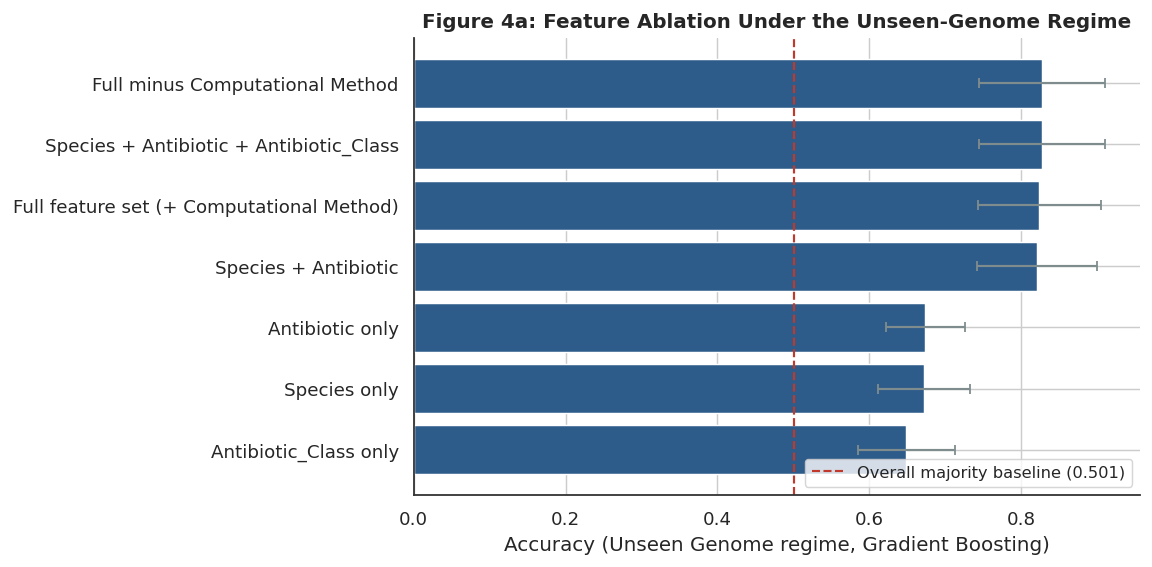

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = ablation_table.sort_values('accuracy_mean').reset_index(drop=True)
ax.barh(order['feature_set'], order['accuracy_mean'], xerr=order['accuracy_std'],
        color=PALETTE['primary'], error_kw=dict(ecolor=PALETTE['neutral'], capsize=3))
ax.axvline(overall_majority_baseline, linestyle='--', color=PALETTE['secondary'],
           label=f'Overall majority baseline ({overall_majority_baseline:.3f})')
ax.set_xlabel('Accuracy (Unseen Genome regime, Gradient Boosting)')
ax.set_title('Figure 4a: Feature Ablation Under the Unseen-Genome Regime', fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure4a_feature_ablation.png", bbox_inches="tight")
plt.show()


**Interpretation.** Comparing the `Species + Antibiotic` row to the leakage-safe
Species+Antibiotic memorization baseline evaluated under the same Unseen Genome regime
(Section 13) tells us how much of a Species+Antibiotic-based classifier's performance is
attributable to something beyond simple majority lookup. High accuracy from `Species only`
or `Antibiotic only` alone should not be read as sophisticated biological learning — it
reflects the class-imbalance structure within those groups (Section 5), not a mechanistic
model of resistance.

---
# 13. Computational Method Ablation

`Computational Method` records which upstream BV-BRC pipeline produced/supported a given
call (`SIR XGBoost Model` or `AdaBoost Classifier` among labeled rows — Section 5). Because
this field is associated with data provenance rather than biology, and was flagged in
Section 4 as strongly associated with which rows even have labels at all, we treat it as a
**potential shortcut/confounder** and explicitly test how much it contributes to measured
performance.

In [ ]:
comp_method_by_species = pd.crosstab(df['Species'], df['Computational Method'])
comp_method_by_label = pd.crosstab(df['Computational Method'], df['Resistant Phenotype'])
print("Computational Method x Species (labeled data):")
print(comp_method_by_species)
print()
print("Computational Method x Resistant Phenotype (labeled data):")
print(comp_method_by_label)
print()
print("Computational Method values found ONLY among unlabeled rows (excluded from all modeling):")
print(df_raw.loc[df_raw['Resistant Phenotype'].isna(), 'Computational Method'].value_counts())

Computational Method x Species (labeled data):
Computational Method   AdaBoost Classifier  SIR XGBoost Model
Species                                                      
Enterococcus faecium                     0                 20
Escherichia coli                         0                217
Klebsiella pneumoniae                   84                  0
Salmonella enterica                      0                280
Staphylococcus aureus                   80                120

Computational Method x Resistant Phenotype (labeled data):
Resistant Phenotype   Resistant  Susceptible
Computational Method                        
AdaBoost Classifier          68           96
SIR XGBoost Model           332          305

Computational Method values found ONLY among unlabeled rows (excluded from all modeling):
Computational Method
MIC XGBoost Model    692
Name: count, dtype: int64


In [ ]:
comp_ablation_rows = []
for name, cols in [('Full feature set (+ Computational Method)', FEATURES_FULL),
                    ('Full minus Computational Method', FEATURES_NO_COMPMETHOD)]:
    for regime_name, splitter in [('Unseen Species-Antibiotic', split_unseen_sa),
                                   ('Unseen Genome', split_unseen_genome)]:
        m, _, _ = run_regime(df, y_all, cols, splitter, f"{regime_name} | {name}",
                              models={'Gradient Boosting': GradientBoostingClassifier(random_state=SEED)},
                              include_baselines=False)
        comp_ablation_rows.append(dict(regime=regime_name, feature_set=name,
                                        accuracy_mean=m['accuracy'].mean(), f1_mean=m['f1'].mean(),
                                        roc_auc_mean=m['roc_auc'].mean()))

comp_ablation_table = pd.DataFrame(comp_ablation_rows).round(3)
comp_ablation_pivot = comp_ablation_table.pivot(index='regime', columns='feature_set', values='accuracy_mean')
comp_ablation_pivot['delta_accuracy_pp'] = (
    (comp_ablation_pivot['Full feature set (+ Computational Method)'] -
     comp_ablation_pivot['Full minus Computational Method']) * 100
).round(2)
comp_ablation_pivot


feature_set,Full feature set (+ Computational Method),Full minus Computational Method,delta_accuracy_pp
regime,,,
Unseen Genome,0.824,0.828,-0.4
Unseen Species-Antibiotic,0.628,0.602,2.6


**Interpretation.** If including `Computational Method` meaningfully improves accuracy
under the grouped regimes above, that is evidence the model is partly exploiting a
provenance/pipeline signal (which pipeline processed a given record) rather than purely
biological information about the species-antibiotic relationship — a form of shortcut
learning. This is reported as a possible explanation, not proof of a specific mechanism, and
the magnitude of the effect (whatever it turns out to be) is what should inform whether
`Computational Method` belongs in a deployment-realistic feature set for any future
publication draft.

---
# 14. Robustness Analysis (Model-Seed Robustness)

This section varies **only the model's internal random seed** (initialization, bootstrap
sampling inside Random Forest/Gradient Boosting/XGBoost) while holding the fold structure of
each regime fixed. This is deliberately kept separate from split uncertainty (Section 11b):
a model can be very stable across seeds while the underlying split-to-split estimate is still
noisy, and vice versa.

In [ ]:
def seed_robustness(df, y, feature_cols, splitter_fn, regime_name, seeds=ROBUSTNESS_SEEDS):
    rows = []
    for s in seeds:
        model = GradientBoostingClassifier(random_state=s)
        m, _, _ = run_regime(df, y, feature_cols, splitter_fn, regime_name,
                              models={'Gradient Boosting': model}, seed=s, include_baselines=False)
        rows.append(dict(seed=s, accuracy=m['accuracy'].mean(), f1=m['f1'].mean()))
    return pd.DataFrame(rows)

robustness_results = {}
for regime_name, splitter, feats in [
    ("Random row-level", split_random, FEATURES_FULL),
    ("Unseen Species-Antibiotic", split_unseen_sa, FEATURES_FULL),
    ("Unseen Genome", split_unseen_genome, FEATURES_FULL),
]:
    robustness_results[regime_name] = seed_robustness(df, y_all, feats, splitter, regime_name)

robustness_summary = pd.DataFrame([
    dict(regime=name, mean=r['accuracy'].mean(), std=r['accuracy'].std(),
         min=r['accuracy'].min(), max=r['accuracy'].max(), n_seeds=len(r))
    for name, r in robustness_results.items()
]).round(4)
logger.info("Model-seed robustness (Gradient Boosting, %d seeds, split held fixed within each regime):", len(ROBUSTNESS_SEEDS))
robustness_summary


,regime,mean,std,min,max,n_seeds
0,Random row-level,0.8242,0.0005,0.8239,0.8252,10
1,Unseen Species-Antibiotic,0.6259,0.0069,0.6079,0.6305,10
2,Unseen Genome,0.8300,0.0017,0.8276,0.8326,10


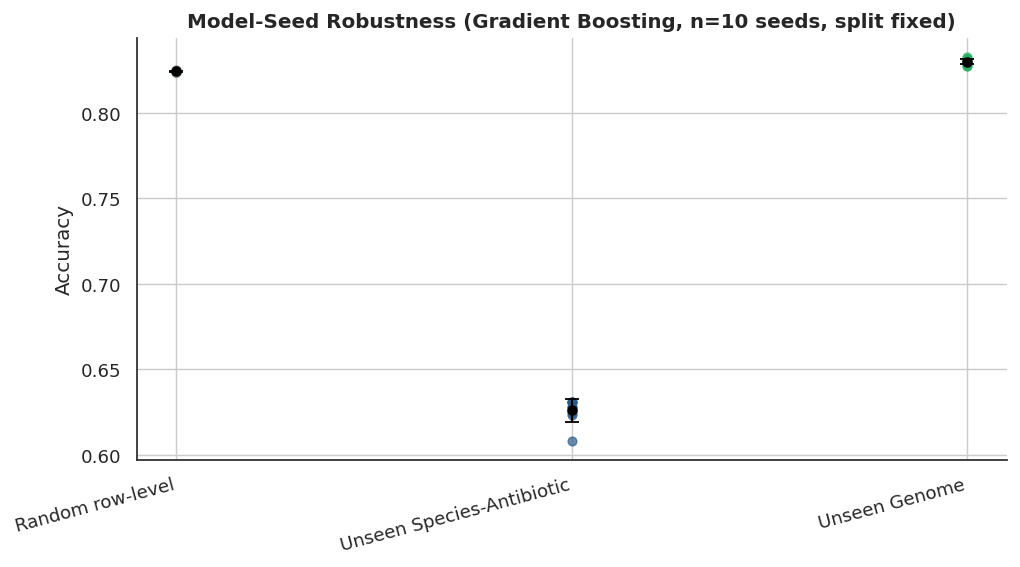

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (name, r) in enumerate(robustness_results.items()):
    ax.scatter([i] * len(r), r['accuracy'], color=REGIME_COLORS.get(name, PALETTE['primary']), alpha=0.7)
    ax.errorbar(i, r['accuracy'].mean(), yerr=r['accuracy'].std(), fmt='o', color='black', capsize=4)
ax.set_xticks(range(len(robustness_results)))
ax.set_xticklabels(list(robustness_results.keys()), rotation=15, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title(f'Model-Seed Robustness (Gradient Boosting, n={len(ROBUSTNESS_SEEDS)} seeds, split fixed)', fontweight='bold')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figureS_seed_robustness.png", bbox_inches="tight")
plt.show()

---
# 15. Permutation Test

We test whether observed accuracy under each grouped regime is distinguishable from a null
distribution generated by shuffling the labels while preserving the grouping/fold structure
of that regime. This tests only whether performance beats a shuffled-label null under the
evaluation procedure used — it does **not** prove biological validity of the model.

`N_PERMUTATIONS = 200` (Section 0) is used as a runtime-appropriate compromise; the empirical
p-value formula `p = (1 + #{null >= observed}) / (N_PERMUTATIONS + 1)` is used throughout.

In [ ]:
def permutation_test(df, y, feature_cols, splitter_fn, regime_name, n_perm=N_PERMUTATIONS, seed=SEED):
    model = GradientBoostingClassifier(random_state=seed)
    m_obs, _, _ = run_regime(df, y, feature_cols, splitter_fn, regime_name,
                              models={'Gradient Boosting': model}, include_baselines=False)
    observed = m_obs['accuracy'].mean()

    rng = np.random.RandomState(seed)
    null_scores = []
    for i in range(n_perm):
        y_shuffled = rng.permutation(y)
        m_null, _, _ = run_regime(df, y_shuffled, feature_cols, splitter_fn, regime_name,
                                   models={'Gradient Boosting': GradientBoostingClassifier(random_state=seed)},
                                   include_baselines=False)
        null_scores.append(m_null['accuracy'].mean())
    null_scores = np.array(null_scores)
    p_value = (1 + (null_scores >= observed).sum()) / (n_perm + 1)
    return dict(regime=regime_name, observed=observed, null_mean=null_scores.mean(),
                null_std=null_scores.std(), n_permutations=n_perm, p_value=p_value), null_scores

logger.info("Running permutation test for the Unseen Genome regime (%d permutations)... this is the most "
            "computationally expensive cell in the notebook.", N_PERMUTATIONS)
perm_result_genome, null_dist_genome = permutation_test(df, y_all, FEATURES_FULL, split_unseen_genome,
                                                          "Unseen Genome")
perm_table = pd.DataFrame([perm_result_genome]).round(4)
perm_table

,regime,observed,null_mean,null_std,n_permutations,p_value
0,Unseen Genome,0.8238,0.4988,0.0233,200,0.005


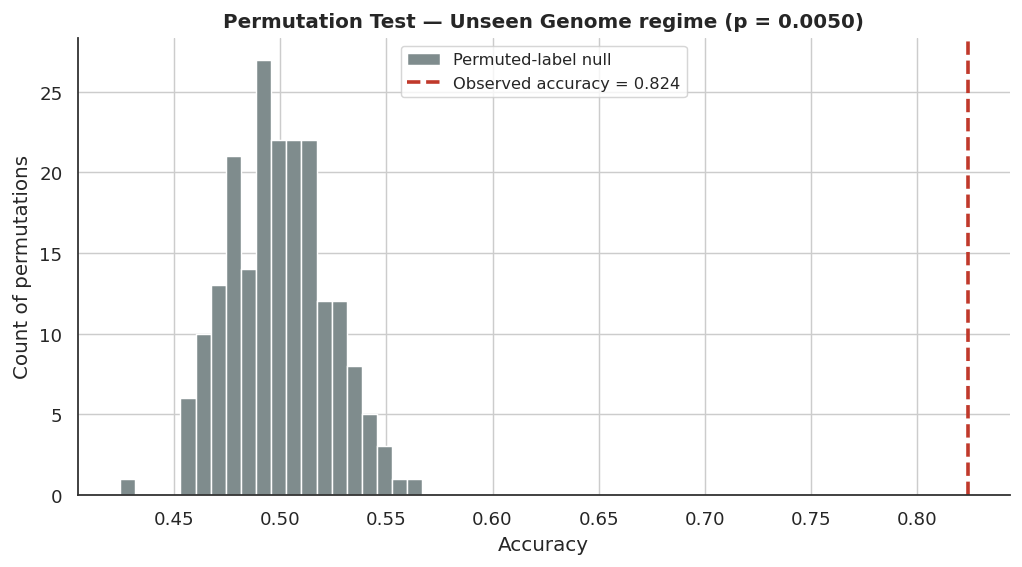

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(null_dist_genome, bins=20, color=PALETTE['neutral'], edgecolor='white', label='Permuted-label null')
ax.axvline(perm_result_genome['observed'], color=PALETTE['secondary'], linestyle='--', linewidth=2,
           label=f"Observed accuracy = {perm_result_genome['observed']:.3f}")
ax.set_xlabel('Accuracy'); ax.set_ylabel('Count of permutations')
ax.set_title(f"Permutation Test — Unseen Genome regime (p = {perm_result_genome['p_value']:.4f})", fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figureS_permutation_test.png", bbox_inches="tight")
plt.show()


---
# 16. Diagnostic Analysis

Diagnostics (confusion matrix, ROC, precision-recall, calibration) are shown for **one**
explicitly named model and regime, rather than an arbitrary fold, so the reader knows exactly
what is being visualized: **Random Forest, Unseen Species-Antibiotic regime, fold 0**
(the same grouped holdout used for feature-importance analysis in Section 19, for
consistency across the notebook).

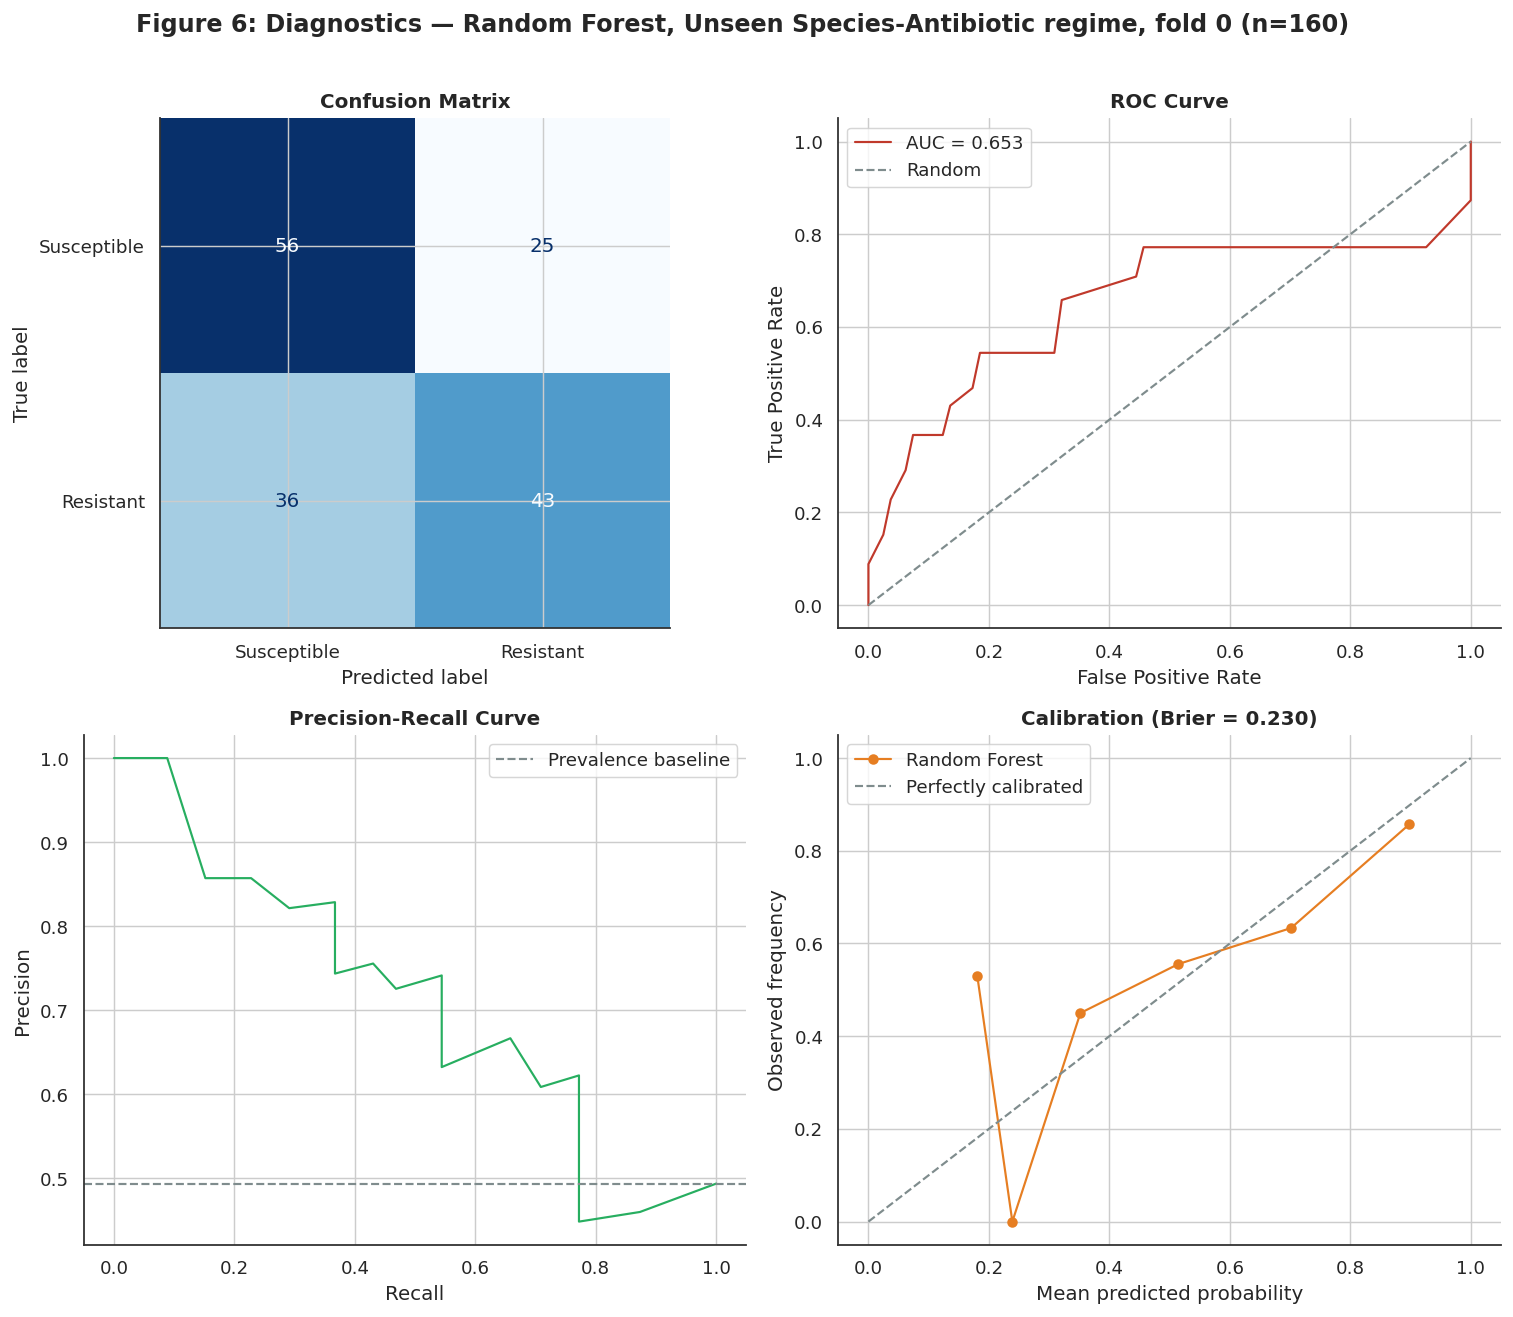

Sensitivity: 0.544   Specificity: 0.691   Balanced accuracy: 0.618


In [ ]:
diag_regime_name = "Unseen Species-Antibiotic"
diag_model_name = "Random Forest"

diag_fold = next((fold_id, name, te_idx, yte, pred, proba)
                  for (fold_id, name, te_idx, yte, pred, proba) in preds_sa
                  if name == diag_model_name and fold_id == 0)
_, _, diag_te_idx, diag_yte, diag_pred, diag_proba = diag_fold

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

cm = confusion_matrix(diag_yte, diag_pred)
ConfusionMatrixDisplay(cm, display_labels=['Susceptible', 'Resistant']).plot(ax=axes[0, 0], cmap='Blues', colorbar=False)
axes[0, 0].set_title('Confusion Matrix', fontweight='bold')

fpr, tpr, _ = roc_curve(diag_yte, diag_proba)
axes[0, 1].plot(fpr, tpr, color=PALETTE['secondary'], label=f'AUC = {roc_auc_score(diag_yte, diag_proba):.3f}')
axes[0, 1].plot([0, 1], [0, 1], linestyle='--', color=PALETTE['neutral'], label='Random')
axes[0, 1].set_xlabel('False Positive Rate'); axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve', fontweight='bold'); axes[0, 1].legend()

prec, rec, _ = precision_recall_curve(diag_yte, diag_proba)
axes[1, 0].plot(rec, prec, color=PALETTE['tertiary'])
axes[1, 0].axhline(diag_yte.mean(), linestyle='--', color=PALETTE['neutral'], label='Prevalence baseline')
axes[1, 0].set_xlabel('Recall'); axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve', fontweight='bold'); axes[1, 0].legend()

frac_pos, mean_pred = calibration_curve(diag_yte, diag_proba, n_bins=6, strategy='quantile')
axes[1, 1].plot(mean_pred, frac_pos, marker='o', color=PALETTE['highlight'], label=diag_model_name)
axes[1, 1].plot([0, 1], [0, 1], linestyle='--', color=PALETTE['neutral'], label='Perfectly calibrated')
axes[1, 1].set_xlabel('Mean predicted probability'); axes[1, 1].set_ylabel('Observed frequency')
axes[1, 1].set_title(f'Calibration (Brier = {brier_score_loss(diag_yte, diag_proba):.3f})', fontweight='bold')
axes[1, 1].legend()

fig.suptitle(f'Figure 6: Diagnostics — {diag_model_name}, {diag_regime_name} regime, fold 0 (n={len(diag_yte)})',
             fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure6_diagnostics.png", bbox_inches="tight")
plt.show()

print(f"Sensitivity: {recall_score(diag_yte, diag_pred, pos_label=1):.3f}   "
      f"Specificity: {recall_score(diag_yte, diag_pred, pos_label=0):.3f}   "
      f"Balanced accuracy: {balanced_accuracy_score(diag_yte, diag_pred):.3f}")


---
# 17. Error Analysis

Errors from the same fold/model shown above (Random Forest, Unseen Species-Antibiotic,
fold 0) are broken down by Species, Antibiotic Class, and Species-Antibiotic combination.
A minimum group size of 5 is required before a subgroup accuracy is reported without a
small-sample flag, to avoid overinterpreting tiny groups.

In [ ]:
MIN_GROUP_SIZE = 5

error_df = df.iloc[diag_te_idx][['Species', 'Antibiotic', 'Antibiotic_Class', 'combo',
                                  'Resistant Phenotype', 'sa_conflicted']].copy()
error_df['predicted_label'] = np.where(diag_pred == 1, 'Resistant', 'Susceptible')
error_df['correct'] = error_df['Resistant Phenotype'] == error_df['predicted_label']
error_df['false_positive'] = (~error_df['correct']) & (error_df['predicted_label'] == 'Resistant')
error_df['false_negative'] = (~error_df['correct']) & (error_df['predicted_label'] == 'Susceptible')

def subgroup_breakdown(error_df, key_col, min_n=MIN_GROUP_SIZE):
    g = error_df.groupby(key_col).agg(
        n=('correct', 'size'), n_correct=('correct', 'sum'),
        n_false_positive=('false_positive', 'sum'), n_false_negative=('false_negative', 'sum'))
    g['accuracy'] = g['n_correct'] / g['n']
    g['n_incorrect'] = g['n'] - g['n_correct']
    g['small_sample_flag'] = g['n'] < min_n
    return g.sort_values('n', ascending=False)

species_error = subgroup_breakdown(error_df, 'Species')
class_error = subgroup_breakdown(error_df, 'Antibiotic_Class')
combo_error = subgroup_breakdown(error_df, 'combo')

print(f"Overall test-set accuracy (this fold): {error_df['correct'].mean():.3f}  (n={len(error_df)})")
print("\nBy species (small_sample_flag = True means n < %d, interpret with caution):" % MIN_GROUP_SIZE)
print(species_error.round(3))

Overall test-set accuracy (this fold): 0.619  (n=160)

By species (small_sample_flag = True means n < 5, interpret with caution):
                        n  n_correct  n_false_positive  n_false_negative  \
Species                                                                    
Salmonella enterica    56         44                 0                12   
Escherichia coli       42         35                 7                 0   
Staphylococcus aureus  40         11                10                19   
Klebsiella pneumoniae  18          9                 4                 5   
Enterococcus faecium    4          0                 4                 0   

                       accuracy  n_incorrect  small_sample_flag  
Species                                                          
Salmonella enterica       0.786           12              False  
Escherichia coli          0.833            7              False  
Staphylococcus aureus     0.275           29              False  
Klebsie

In [ ]:
print("By antibiotic class:")
class_error.round(3)

By antibiotic class:


,n,n_correct,n_false_positive,n_false_negative,accuracy,n_incorrect,small_sample_flag
Antibiotic_Class,,,,,,,
Aminoglycoside,41,30,3,8,0.732,11,False
Folate inhibitor,26,11,10,5,0.423,15,False
Penicillin,21,15,2,4,0.714,6,False
Macrolide,20,1,0,19,0.050,19,False
Aminocyclitol,14,14,0,0,1.000,0,False
Carbapenem,7,6,1,0,0.857,1,False
Cephalosporin,7,6,1,0,0.857,1,False
Tetracycline,7,5,2,0,0.714,2,False
Sulfonamide,7,6,1,0,0.857,1,False


In [ ]:
print("Species-Antibiotic combinations with at least one error, sorted by n:")
combo_error[combo_error['n_incorrect'] > 0].round(3).head(15)

Species-Antibiotic combinations with at least one error, sorted by n:


,n,n_correct,n_false_positive,n_false_negative,accuracy,n_incorrect,small_sample_flag
combo,,,,,,,
Staphylococcus aureus | trimethoprim/sulfamethoxazole,20,10,10,0,0.500,10,False
Staphylococcus aureus | erythromycin,20,1,0,19,0.050,19,False
Salmonella enterica | amoxicillin/clavulanic acid,14,10,0,4,0.714,4,False
Salmonella enterica | gentamicin,14,6,0,8,0.429,8,False
Escherichia coli | amoxicillin/clavulanic acid,7,5,2,0,0.714,2,False
Escherichia coli | cefazolin,7,6,1,0,0.857,1,False
Escherichia coli | meropenem,7,6,1,0,0.857,1,False
Escherichia coli | doxycycline,7,5,2,0,0.714,2,False
Escherichia coli | sulfamethoxazole,7,6,1,0,0.857,1,False


---
# 18. Conflict-vs-Nonconflict Analysis

Does a Species+Antibiotic (or Genome+Antibiotic) relationship that contains **both** R and S
labels elsewhere in the dataset (Section 4d) correspond to harder-to-predict rows? We compare
model accuracy on rows belonging to conflicting vs. consistent groups, using the pooled
Unseen Species-Antibiotic regime predictions (Gradient Boosting) across all 5 folds so the
comparison is not limited to a single fold's sample size.

In [ ]:
gb_sa_pooled = pool_predictions([p for p in preds_sa if p[1] == 'Gradient Boosting'],
                                 lambda idx: df.iloc[idx]['combo'].values)
gb_sa_pooled['sa_conflicted'] = gb_sa_pooled['group'].isin(sa_conflicted_set)
gb_sa_pooled['correct'] = gb_sa_pooled['y_true'] == gb_sa_pooled['y_pred']

conflict_perf = gb_sa_pooled.groupby('sa_conflicted').agg(
    n=('correct', 'size'), accuracy=('correct', 'mean')).round(3)
conflict_perf.index = ['Consistent S-A combo', 'Conflicting S-A combo']
print("Gradient Boosting, Unseen Species-Antibiotic regime, all folds pooled:")
conflict_perf

Gradient Boosting, Unseen Species-Antibiotic regime, all folds pooled:


,n,accuracy
Consistent S-A combo,315,0.721
Conflicting S-A combo,486,0.568


In [ ]:
# Same comparison, Genome+Antibiotic conflict status, under the Unseen Genome regime
gb_genome_pooled = pool_predictions([p for p in preds_genome if p[1] == 'Gradient Boosting'],
                                     lambda idx: df.iloc[idx]['genome_antibiotic'].values)
gb_genome_pooled['ga_conflicted'] = gb_genome_pooled['group'].isin(ga_conflicted_set)
gb_genome_pooled['correct'] = gb_genome_pooled['y_true'] == gb_genome_pooled['y_pred']

conflict_perf_ga = gb_genome_pooled.groupby('ga_conflicted').agg(
    n=('correct', 'size'), accuracy=('correct', 'mean')).round(3)
conflict_perf_ga.index = ['Consistent Genome-Antibiotic combo', 'Conflicting Genome-Antibiotic combo']
print("Gradient Boosting, Unseen Genome regime, all folds pooled:")
conflict_perf_ga

Gradient Boosting, Unseen Genome regime, all folds pooled:


,n,accuracy
Consistent Genome-Antibiotic combo,777,0.834
Conflicting Genome-Antibiotic combo,24,0.500


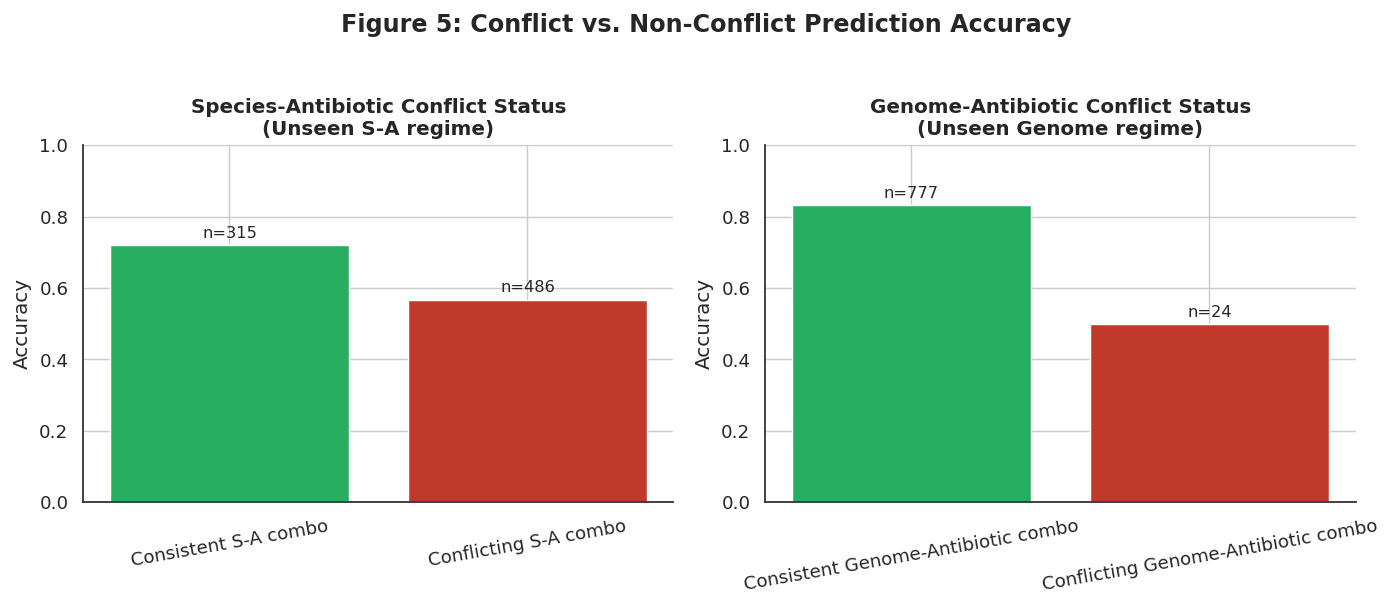

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(conflict_perf.index, conflict_perf['accuracy'], color=[PALETTE['tertiary'], PALETTE['secondary']])
for i, (n, acc) in enumerate(zip(conflict_perf['n'], conflict_perf['accuracy'])):
    axes[0].text(i, acc + 0.02, f'n={n}', ha='center', fontsize=9)
axes[0].set_ylim(0, 1); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Species-Antibiotic Conflict Status\n(Unseen S-A regime)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=10)

axes[1].bar(conflict_perf_ga.index, conflict_perf_ga['accuracy'], color=[PALETTE['tertiary'], PALETTE['secondary']])
for i, (n, acc) in enumerate(zip(conflict_perf_ga['n'], conflict_perf_ga['accuracy'])):
    axes[1].text(i, acc + 0.02, f'n={n}', ha='center', fontsize=9)
axes[1].set_ylim(0, 1); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Genome-Antibiotic Conflict Status\n(Unseen Genome regime)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=10)

fig.suptitle('Figure 5: Conflict vs. Non-Conflict Prediction Accuracy', fontweight='bold', y=1.03)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure5_conflict_analysis.png", bbox_inches="tight")
plt.show()

**Interpretation.** Whatever direction this comparison shows, the conflict itself is only
a *label-consistency* property of the dataset. Possible explanations for why conflicting
groups might be harder (or not) include isolate-level biological variation, testing-method
differences, differences between the upstream Computational Methods used across records
(Section 13), or data-integration artifacts. This notebook does not have evidence to select
one explanation as correct, and none is claimed as such.

---
# 19. Feature Importance

Primary interpretation method: **permutation importance on held-out data** (Random Forest,
Unseen Species-Antibiotic regime, fold 0 — same fold as Sections 16-17). Tree impurity
importance is included as secondary/exploratory evidence only. Because categorical variables
are one-hot encoded, importances for each original categorical column are summed across all
of its one-hot indicator columns, so the plot reflects `Species`, `Antibiotic`,
`Antibiotic_Class`, and `Computational Method` as single interpretable units.

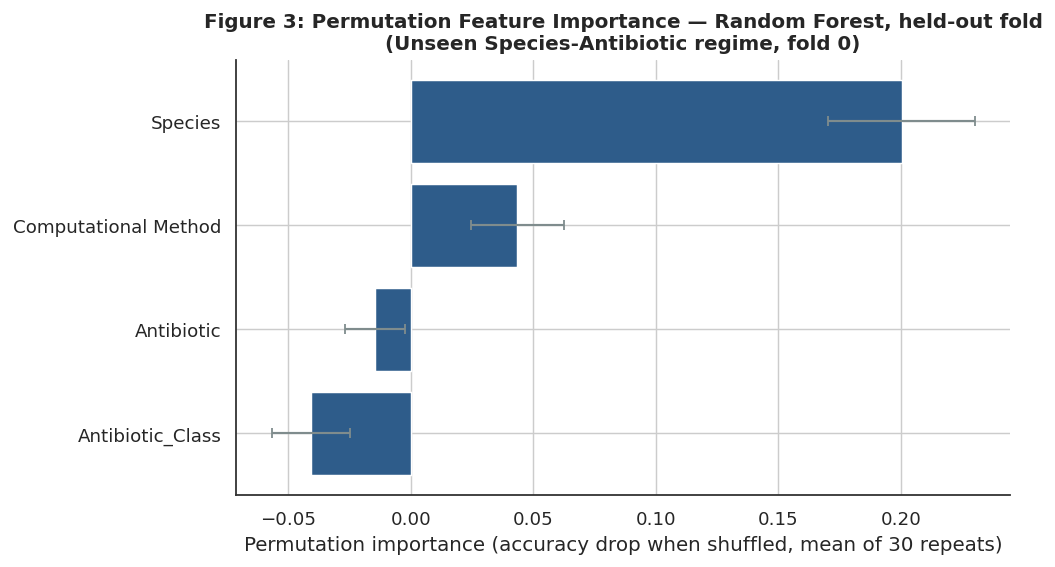

,permutation_importance_mean
Species,0.200208
Computational Method,0.043542
Antibiotic,-0.014583
Antibiotic_Class,-0.040833


In [ ]:
tr_idx_fold0, te_idx_fold0 = None, None
gkf_sa_for_fi = GroupKFold(n_splits=N_SPLITS_GROUPED)
for i, (tr, te) in enumerate(gkf_sa_for_fi.split(df, y_all, groups=df['combo'].values)):
    if i == 0:
        tr_idx_fold0, te_idx_fold0 = tr, te
        break

rf_pipe = make_pipeline(RandomForestClassifier(n_estimators=300, random_state=SEED), FEATURES_FULL)
rf_pipe.fit(df.iloc[tr_idx_fold0][FEATURES_FULL], y_all[tr_idx_fold0])

perm_imp = permutation_importance(rf_pipe, df.iloc[te_idx_fold0][FEATURES_FULL], y_all[te_idx_fold0],
                                   n_repeats=30, random_state=SEED, scoring='accuracy')

# NOTE: permutation_importance shuffles at the *pipeline input* level, i.e. the 4 raw
# categorical columns in FEATURES_FULL -- NOT the expanded one-hot columns. So no one-hot
# aggregation is needed here (unlike the impurity/SHAP importances below, which operate on
# the fitted model's internal one-hot representation and do require aggregation).
grouped_importance = pd.Series(perm_imp.importances_mean, index=FEATURES_FULL).sort_values(ascending=True)
grouped_importance_std = pd.Series(perm_imp.importances_std, index=FEATURES_FULL)[grouped_importance.index]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(grouped_importance.index, grouped_importance.values, xerr=grouped_importance_std.values,
        color=PALETTE['primary'], error_kw=dict(ecolor=PALETTE['neutral'], capsize=3))
ax.set_xlabel('Permutation importance (accuracy drop when shuffled, mean of 30 repeats)')
ax.set_title('Figure 3: Permutation Feature Importance — Random Forest, held-out fold\n(Unseen Species-Antibiotic regime, fold 0)', fontweight='bold')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure3_feature_importance.png", bbox_inches="tight")
plt.show()

grouped_importance.sort_values(ascending=False).to_frame('permutation_importance_mean')

In [ ]:
# Secondary/exploratory: tree impurity importance operates on the FITTED model's one-hot
# representation directly, so it DOES need aggregation back to the original categorical column.
ohe_feature_names = rf_pipe.named_steps['prep'].get_feature_names_out()
def base_feature(name):
    stripped = name.split('__', 1)[-1]
    for col in FEATURES_FULL:
        if stripped.startswith(col):
            return col
    return stripped

impurity_imp = pd.Series(rf_pipe.named_steps['clf'].feature_importances_, index=ohe_feature_names)
impurity_grouped = pd.DataFrame({'ohe_feature': ohe_feature_names, 'importance': impurity_imp.values})
impurity_grouped['base_feature'] = impurity_grouped['ohe_feature'].apply(base_feature)
impurity_summary = impurity_grouped.groupby('base_feature')['importance'].sum().sort_values(ascending=False)
print("Secondary evidence — Random Forest impurity-based importance (summed by original feature):")
impurity_summary.to_frame('summed_impurity_importance')

Secondary evidence — Random Forest impurity-based importance (summed by original feature):


,summed_impurity_importance
base_feature,
Antibiotic,0.595009
Species,0.340647
Computational Method,0.064344


**Interpretation.** Language throughout this section is deliberately "the model relied
on..." rather than "this feature causes resistance" — feature importance describes what the
fitted model used to make predictions, not a biological mechanism.

---
# 20. SHAP / Model Interpretation (secondary)

SHAP is used as a secondary interpretability check on the same fitted Random Forest and
held-out fold as Section 19. We explicitly resolve which slice of SHAP's output corresponds
to the `Resistant` class rather than assuming array order, and aggregate one-hot SHAP values
back to the original categorical feature level.

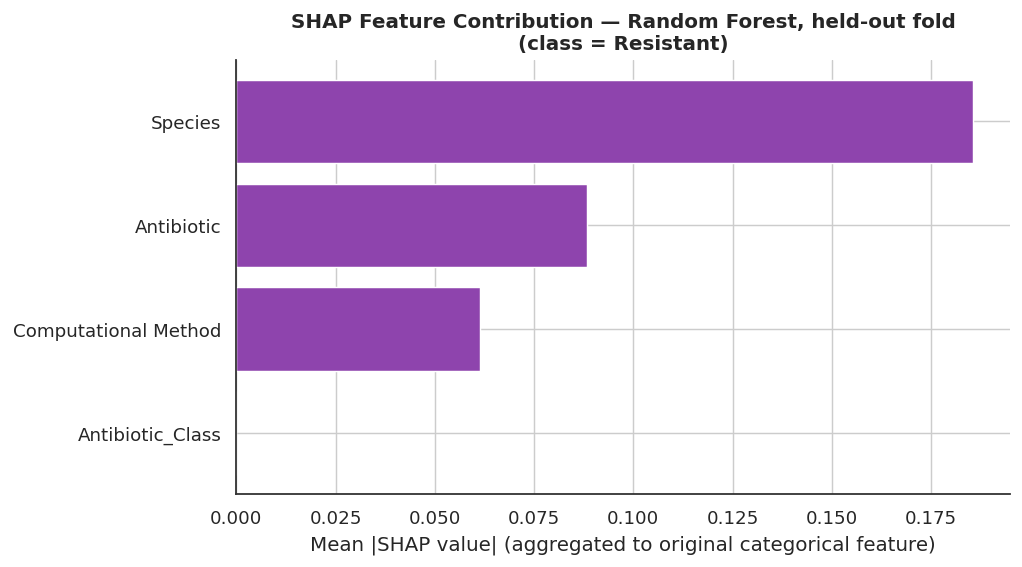

In [ ]:
explainer = shap.TreeExplainer(rf_pipe.named_steps['clf'])
X_te_ohe = rf_pipe.named_steps['prep'].transform(df.iloc[te_idx_fold0][FEATURES_FULL])
X_te_ohe = np.asarray(X_te_ohe.todense() if hasattr(X_te_ohe, 'todense') else X_te_ohe, dtype=float)
shap_values_raw = explainer.shap_values(X_te_ohe)

target_class_label = 'Resistant'  # y=1
model_classes = list(rf_pipe.named_steps['clf'].classes_)
class_idx = model_classes.index(1)
logger.info("SHAP: model.classes_=%s | target='%s' (y=1) resolves to class_idx=%d",
            model_classes, target_class_label, class_idx)

if isinstance(shap_values_raw, list):
    sv_for_class = shap_values_raw[class_idx]
elif np.asarray(shap_values_raw).ndim == 3:
    sv_for_class = shap_values_raw[:, :, class_idx]
else:
    sv_for_class = shap_values_raw

# Aggregate one-hot SHAP values back to the original categorical feature (sum |SHAP| across
# the one-hot columns belonging to each base feature, per row, then take the mean).
sv_df = pd.DataFrame(sv_for_class, columns=ohe_feature_names)
agg_sv = pd.DataFrame({col: sv_df[[c for c in ohe_feature_names if base_feature(c) == col]].sum(axis=1)
                        for col in FEATURES_FULL})

fig, ax = plt.subplots(figsize=(8, 4.5))
mean_abs_shap = agg_sv.abs().mean().sort_values(ascending=True)
ax.barh(mean_abs_shap.index, mean_abs_shap.values, color=PALETTE['purple'])
ax.set_xlabel('Mean |SHAP value| (aggregated to original categorical feature)')
ax.set_title('SHAP Feature Contribution — Random Forest, held-out fold\n(class = Resistant)', fontweight='bold')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figureS_shap_summary.png", bbox_inches="tight")
plt.show()

**Scope note.** SHAP here answers "what did the model use", not "what biological
mechanism causes resistance." Category IDs are never interpreted as ordinal biological
quantities; SHAP is read at the categorical-feature level (e.g. "Antibiotic" as a whole
contributed X on average), consistent with the one-hot encoding used throughout.

---
# 21. Learning Curves

The training-set-size baseline is computed directly from the actual training data at each
point on the curve rather than a single hard-coded number (a bug fixed from the previous
notebook version, which used a hard-coded 0.593 baseline that did not match this dataset's
overall ~50/50 class balance).

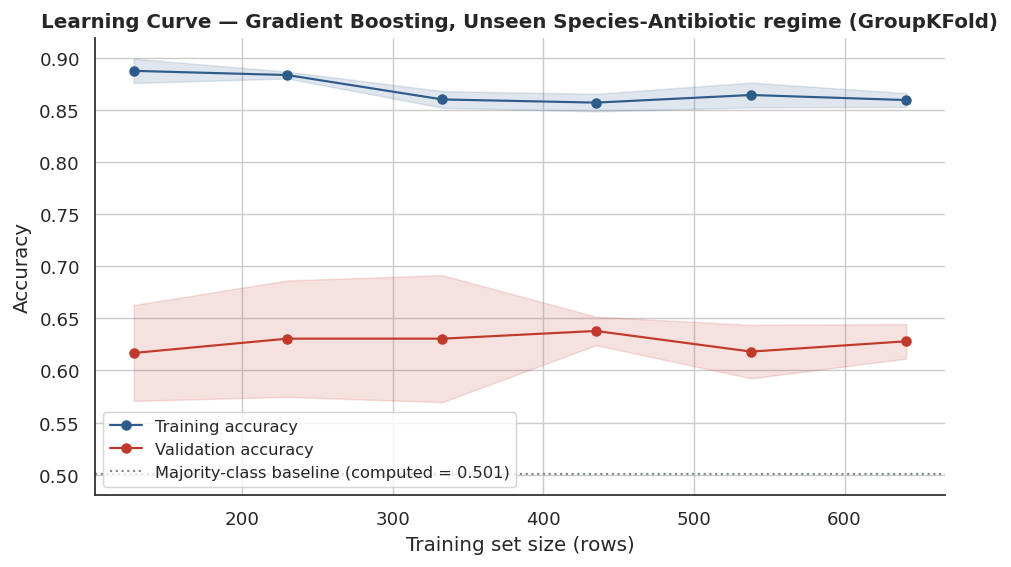

In [ ]:
gb_for_lc = GradientBoostingClassifier(random_state=SEED)
lc_pipe = make_pipeline(gb_for_lc, FEATURES_FULL)
gkf_lc = GroupKFold(n_splits=N_SPLITS_GROUPED)

train_sizes, train_scores, val_scores = learning_curve(
    lc_pipe, df[FEATURES_FULL], y_all, groups=df['combo'].values, cv=gkf_lc,
    train_sizes=np.linspace(0.2, 1.0, 6), scoring='accuracy')

overall_majority_dynamic = pd.Series(y_all).value_counts(normalize=True).max()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color=PALETTE['primary'], label='Training accuracy')
ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color=PALETTE['primary'])
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', color=PALETTE['secondary'], label='Validation accuracy')
ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color=PALETTE['secondary'])
ax.axhline(overall_majority_dynamic, linestyle=':', color=PALETTE['neutral'],
           label=f'Majority-class baseline (computed = {overall_majority_dynamic:.3f})')
ax.set_xlabel('Training set size (rows)'); ax.set_ylabel('Accuracy')
ax.set_title('Learning Curve — Gradient Boosting, Unseen Species-Antibiotic regime (GroupKFold)', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figureS_learning_curve.png", bbox_inches="tight")
plt.show()

---
# 22. Calibration / Sensitivity / Specificity Summary

Section 16 shows full diagnostics for one fold. Here we summarize sensitivity, specificity,
and Brier score for Gradient Boosting across all four regimes, for a compact cross-regime
comparison.

In [ ]:
calib_summary = MAIN_RESULTS[MAIN_RESULTS['model'] == 'Gradient Boosting'][
    ['regime', 'sensitivity_mean', 'specificity_mean', 'brier_mean']].round(3)
calib_summary.columns = ['Regime', 'Sensitivity (mean)', 'Specificity (mean)', 'Brier score (mean)']
calib_summary

,Regime,Sensitivity (mean),Specificity (mean),Brier score (mean)
5,Random row-level,0.807,0.840,0.128
14,Unseen Species-Antibiotic,0.582,0.691,0.241
23,Unseen Genome,0.806,0.849,0.135
32,Leave-One-Species-Out,0.593,0.418,0.348


---
# 23. Dataset and Methodological Limitations

**Label provenance.** The `Resistant Phenotype` labels used throughout are BV-BRC-recorded
values associated with upstream laboratory and computational methods (Section 2). They are
not independently re-verified laboratory ground truth collected by this project. All results
above describe prediction of *these recorded labels*, not "true clinical AMR."

**Dataset size.** Only 801 labeled observations, 41 genomes, 5 species, and 82
Species-Antibiotic combinations are available. Leave-One-Species-Out in particular rests on
only 5 held-out groups — it is reported as a small-sample exploratory analysis, not a
statistically powered generalization claim, and no bootstrap confidence interval is claimed
for it (Section 11b).

**Genomic data.** This project is entirely metadata-based (Species, Antibiotic, Antibiotic
Class, Computational Method). No genomic/sequence features are used. This notebook does not
claim to perform "genomic AMR prediction" (DNA sequence -> resistance); a genomic extension
would be a natural future direction if an appropriate sequence-linked dataset became
available, but is out of scope here.

**Antibiotic Class mapping.** `Antibiotic_Class` is a manually curated pharmacological
grouping (Section 7a), not an authoritative BV-BRC field. It should not be cited as
dataset-native metadata in any downstream publication draft.

**External validation.** External validation was not performed because an independent
validation dataset was not available to this project. No external-validation experiment is
manufactured or implied anywhere in this notebook.

**Upstream BV-BRC model comparison.** `Computational Method Performance` contains upstream
self-reported performance figures (e.g. an F1 score) for the pipelines that produced some of
these labels. These are **not directly comparable** to the grouped-evaluation metrics computed
in this notebook: they were generated under different (and to us, unknown) data, targets,
splits, and evaluation procedures. Any gap between an upstream self-reported figure and our
grouped-regime metrics should be read as *provenance context*, not as a direct performance comparison.

In [ ]:
def parse_upstream_f1(perf_str):
    """Extract a self-reported F1 score from BV-BRC's free-text 'Computational Method Performance' field, if present."""
    import re
    if pd.isna(perf_str):
        return None
    m = re.search(r'F1[\s\w]*:\s*([\d.]+)', str(perf_str))
    return float(m.group(1)) if m else None

df['bvbrc_reported_f1'] = df['Computational Method Performance'].apply(parse_upstream_f1)
upstream_f1_by_method = df.groupby('Computational Method')['bvbrc_reported_f1'].agg(['mean', 'count'])
print("Upstream (BV-BRC) self-reported F1, by Computational Method (context only, not a fair comparison target):")
print(upstream_f1_by_method.round(3))
print()
print("This notebook's grouped-evaluation F1 for reference (Gradient Boosting, Unseen Species-Antibiotic):")
our_f1 = MAIN_RESULTS.loc[(MAIN_RESULTS['model']=='Gradient Boosting') &
                          (MAIN_RESULTS['regime']=='Unseen Species-Antibiotic'), 'f1_mean'].values[0]
print(f"  {our_f1:.3f}")
print()
print("As noted above, these two numbers are NOT apples-to-apples: different data, targets, "
      "splits, and evaluation procedures. No 'X points worse' claim is made.")


Upstream (BV-BRC) self-reported F1, by Computational Method (context only, not a fair comparison target):
                       mean  count
Computational Method              
AdaBoost Classifier   0.913    164
SIR XGBoost Model     0.927    637

This notebook's grouped-evaluation F1 for reference (Gradient Boosting, Unseen Species-Antibiotic):
  0.595

As noted above, these two numbers are NOT apples-to-apples: different data, targets, splits, and evaluation procedures. No 'X points worse' claim is made.


**Intrinsic resistance rules (not used in main analysis).** A prior draft of this notebook
contained an illustrative, incomplete set of intrinsic-resistance species-antibiotic pairs.
Because a complete, authoritative CLSI/EUCAST rule table cross-referenced against all 46
antibiotics in this panel was not supplied to this project, that illustrative rule set has
been **removed from the main analysis** rather than presented as validated biological
ground truth. It is not reintroduced here, consistent with the instruction not to invent
biological rules.

---
# 24. Final Summary

Every value in this section is pulled programmatically from variables computed earlier in
this notebook — nothing here is hard-coded.

In [ ]:
def get_metric(regime, model, metric):
    row = MAIN_RESULTS[(MAIN_RESULTS['regime'] == regime) & (MAIN_RESULTS['model'] == model)]
    return row[f'{metric}_mean'].values[0] if len(row) else np.nan

summary_lines = []
summary_lines.append(f"Dataset: {n_labeled} labeled rows ({(df['Resistant Phenotype']=='Resistant').sum()} Resistant, "
                      f"{(df['Resistant Phenotype']=='Susceptible').sum()} Susceptible) out of {n_total} total rows "
                      f"({n_unlabeled} unlabeled, excluded from all modeling).")
summary_lines.append(f"Structure: {df['Species'].nunique()} species, {df['Genome ID'].nunique()} genomes, "
                      f"{df['Antibiotic'].nunique()} antibiotics, {df['combo'].nunique()} Species-Antibiotic combinations.")
summary_lines.append(f"Label conflicts: {sa_conflict_stats['n_conflicted_groups']} / {sa_conflict_stats['n_groups']} "
                      f"Species-Antibiotic combos ({sa_conflict_stats['pct_groups_conflicted']}%) and "
                      f"{ga_conflict_stats['n_conflicted_groups']} / {ga_conflict_stats['n_groups']} "
                      f"Genome-Antibiotic combos ({ga_conflict_stats['pct_groups_conflicted']}%) contain both R and S labels.")
summary_lines.append(f"Memorization ceilings (in-sample, descriptive): Species+Antibiotic = {sa_ceiling:.3f}, "
                      f"Genome+Antibiotic = {ga_ceiling:.3f}.")
for regime in regime_order:
    acc = get_metric(regime, 'Gradient Boosting', 'accuracy')
    f1 = get_metric(regime, 'Gradient Boosting', 'f1')
    summary_lines.append(f"{regime} (Gradient Boosting): accuracy = {acc:.3f}, F1 = {f1:.3f}.")
summary_lines.append(f"Computational Method ablation: including it changed accuracy by "
                      f"{comp_ablation_pivot['delta_accuracy_pp'].mean():.2f} pp on average across the two grouped "
                      f"regimes tested (Section 13) -- interpreted as evidence about provenance dependence, not "
                      f"biological signal.")
summary_lines.append(f"Model-seed robustness (Gradient Boosting, {len(ROBUSTNESS_SEEDS)} seeds): std of accuracy "
                      f"ranged {robustness_summary['std'].min():.4f}-{robustness_summary['std'].max():.4f} "
                      f"across the three regimes tested.")
summary_lines.append(f"Permutation test (Unseen Genome, {N_PERMUTATIONS} permutations): observed accuracy = "
                      f"{perm_result_genome['observed']:.3f}, null mean = {perm_result_genome['null_mean']:.3f} "
                      f"+/- {perm_result_genome['null_std']:.3f}, p = {perm_result_genome['p_value']:.4f}.")

print("=" * 90)
print("AUTO-GENERATED FINAL SUMMARY (values computed from this run, not hard-coded)")
print("=" * 90)
for line in summary_lines:
    print("- " + line)

AUTO-GENERATED FINAL SUMMARY (values computed from this run, not hard-coded)
- Dataset: 801 labeled rows (400 Resistant, 401 Susceptible) out of 1493 total rows (692 unlabeled, excluded from all modeling).
- Structure: 5 species, 41 genomes, 46 antibiotics, 82 Species-Antibiotic combinations.
- Label conflicts: 56 / 82 Species-Antibiotic combos (68.29%) and 12 / 721 Genome-Antibiotic combos (1.66%) contain both R and S labels.
- Memorization ceilings (in-sample, descriptive): Species+Antibiotic = 0.860, Genome+Antibiotic = 0.985.
- Random row-level (Gradient Boosting): accuracy = 0.824, F1 = 0.820.
- Unseen Species-Antibiotic (Gradient Boosting): accuracy = 0.628, F1 = 0.595.
- Unseen Genome (Gradient Boosting): accuracy = 0.824, F1 = 0.813.
- Leave-One-Species-Out (Gradient Boosting): accuracy = 0.438, F1 = 0.492.
- Computational Method ablation: including it changed accuracy by 1.10 pp on average across the two grouped regimes tested (Section 13) -- interpreted as evidence about prov

## What These Results Do and Do Not Demonstrate

**They do demonstrate:**
- Whether (and by how much) estimated accuracy for these BV-BRC-recorded AMR phenotype
  labels changes across the four evaluation regimes computed above.
- The extent to which simple structural memorization (Species+Antibiotic or
  Genome+Antibiotic majority lookup) accounts for performance under each regime, versus
  what the ML models add beyond that.
- Whether `Computational Method` (a provenance/pipeline field) contributes to predictive
  performance, which bears on shortcut-learning risk.
- Whether label conflicts within a Species+Antibiotic or Genome+Antibiotic group are
  associated with harder-to-predict rows in this dataset.

**They do not demonstrate:**
- True clinical AMR prediction accuracy (labels are BV-BRC-recorded, not independently
  verified lab ground truth — Section 2).
- Genomic/sequence-based AMR prediction (this project is metadata-only).
- Externally validated generalization (no independent dataset was available).
- A specific biological cause for any observed label conflict or feature importance —
  only association, at the level this dataset supports.
- Broad cross-species generalization beyond these 5 species (LOSO here is a small-sample
  exploratory result).

## Reproducibility Information

All results in this notebook are produced by re-running the cells above with `SEED=42` and
the seed lists defined in Section 0. Re-running this notebook top-to-bottom on the same
`BVBRC_genome_amr.csv` file should reproduce every number reported here (permutation test
and robustness cells are the only ones that resample; both use fixed seeds).

---
# 25. Export Publication Tables and Figures

All tables below are written as CSV files to `outputs/`. All figures were already saved as
PNGs to `outputs/` at the point they were generated earlier in the notebook.

In [ ]:
# TABLE 1: Dataset characteristics
table1 = pd.DataFrame([
    dict(metric='Total rows', value=n_total), dict(metric='Labeled rows', value=n_labeled),
    dict(metric='Unlabeled rows', value=n_unlabeled),
    dict(metric='Resistant (labeled)', value=int((df['Resistant Phenotype']=='Resistant').sum())),
    dict(metric='Susceptible (labeled)', value=int((df['Resistant Phenotype']=='Susceptible').sum())),
    dict(metric='Species', value=df['Species'].nunique()), dict(metric='Genomes', value=df['Genome ID'].nunique()),
    dict(metric='Antibiotics', value=df['Antibiotic'].nunique()),
    dict(metric='Species-Antibiotic combinations', value=df['combo'].nunique()),
])
table1.to_csv(OUTPUT_DIR / "table1_dataset_characteristics.csv", index=False)

# TABLE 2: Dependency / overlap audit
split_integrity_table.to_csv(OUTPUT_DIR / "table2_split_integrity_audit.csv", index=False)

# TABLE 3: Memorization baselines (leakage-safe, evaluated under each regime)
baseline_metrics = ALL_METRICS[ALL_METRICS['model'].str.startswith('Baseline:')]
table3 = summarize_metrics(baseline_metrics)
table3.to_csv(OUTPUT_DIR / "table3_memorization_baselines.csv", index=False)

# TABLE 4: Main model performance across four evaluation regimes
MAIN_RESULTS.to_csv(OUTPUT_DIR / "table4_main_results.csv", index=False)

# TABLE 5: Feature ablation
ablation_table.to_csv(OUTPUT_DIR / "table5_feature_ablation.csv", index=False)
comp_ablation_pivot.to_csv(OUTPUT_DIR / "table5b_computational_method_ablation.csv")

# TABLE 6: Error/conflict analysis
species_error.to_csv(OUTPUT_DIR / "table6a_error_by_species.csv")
class_error.to_csv(OUTPUT_DIR / "table6b_error_by_antibiotic_class.csv")
conflict_perf.to_csv(OUTPUT_DIR / "table6c_conflict_vs_nonconflict_sa.csv")
conflict_perf_ga.to_csv(OUTPUT_DIR / "table6d_conflict_vs_nonconflict_ga.csv")

exported = sorted(p.name for p in OUTPUT_DIR.glob("*"))
logger.info("Exported %d files to %s:", len(exported), OUTPUT_DIR.resolve())
for f in exported:
    print(" -", f)

 - fig0_dependency_structure.png
 - figure2_regime_comparison.png
 - figure3_feature_importance.png
 - figure4a_feature_ablation.png
 - figure5_conflict_analysis.png
 - figure6_diagnostics.png
 - figureS_learning_curve.png
 - figureS_permutation_test.png
 - figureS_seed_robustness.png
 - figureS_shap_summary.png
 - table1_dataset_characteristics.csv
 - table2_split_integrity_audit.csv
 - table3_memorization_baselines.csv
 - table4_main_results.csv
 - table5_feature_ablation.csv
 - table5b_computational_method_ablation.csv
 - table6a_error_by_species.csv
 - table6b_error_by_antibiotic_class.csv
 - table6c_conflict_vs_nonconflict_sa.csv
 - table6d_conflict_vs_nonconflict_ga.csv


---
## Notebook Complete

This notebook executes top-to-bottom in a fresh runtime with no manual intermediate steps.
All four evaluation regimes, the split-integrity audit, memorization baselines, feature and
Computational-Method ablations, robustness and permutation testing, error/conflict analysis,
interpretability (permutation importance + SHAP), learning curves, and publication tables/
figures are generated directly from `BVBRC_genome_amr.csv` with no fabricated results.